# **Segment, Predict, Grow:** Unlocking Customer Value with RFM Analysis & Machine Learning 

- Customer Segmentation and CLV Prediction Using RFM Analysis.
- Dataset: UK Online Retail dataset
- Method: Applying RFM analysis and Clustering (K-Means), Predictive Modeling (Regression).

## Overview

### 📦 Background:
The data set contains all the transactions occurring between 01/12/2010 and 09/12/2011 for a UK-based and registered online retail store.The company mainly sells unique all-occasion gifts. Like many e-commerce businesses, the company wants to improve customer retention, marketing effectiveness, and sales performance. However, with thousands of customers and transactions, they need a data-driven way to segment their customers and identify actionable strategies for each segment. 

### 1. 🎯 Business Problem Statement
`“How can we segment customers based on their purchasing behavior to tailor marketing strategies, and predict customer lifetime value (CLV) to focus efforts on high-value customers?”`

To solve this, we apply:
- RFM Analysis to quantify customer engagement
- Clustering (K-Means) to group customers into meaningful segments

### 2. Goals
- Use RFM analysis to segment customers by behavioral value.
- Apply K-Means clustering to identify distinct customer groups.
- Use supervised regression (e.g. linear regression, randomforest, XGBoost) to predict CLV.
- Provide actionable marketing recommendations for different segments.

### 3. Data Preparation
- Remove nulls/cancellations (InvoiceNo starting with 'C' and its corresponding originals).
- Remove negative values in Quantity and UnitPrice.
- Engineer RFM features (Recency, Frequency, Monetary).
- Calculate CLV as:
CLV = Using total purchase value over the dataset as a proxy CLV for the model.
- Additional feature engineering: TotalQuantity, AvgQuantityPerOrder, Tenure Days

### 4. Analysis Approach
A. Segmentation (Unsupervised)
- Use K-Means clustering on scaled/log-transformed RFM features.
- Label segments as: High Value, Mid Value, Low Value, At Risk, etc.
- Visualize clusters (2D/3D plot, boxplots by segment).

B. Predictive Modeling (Supervised Regression)
- Use features: RFM + additional engineered features ('TotalQuantity', 'AvgQuantityPerOrder', 'Tenure').
- Target: CLV proxy
- Models: Linear Regression (quick), RandomForest (best performance), XGBoost 
- Evaluate: RMSE, R2 and feature importance.

### Summary:
- CLV prediction uses the RFM data already calculated for KMeans — adding a predictive layer.
- It deepens the analysis, showing progression from descriptive → prescriptive → predictive.

In [10]:
# Import Libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from yellowbrick.cluster import KElbowVisualizer
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA 
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score

## 1. Data Loading and Cleaning

In [12]:
# Load Dataset
df = pd.read_csv("OnlineRetail.csv", encoding='latin1')  

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


📌 Data Dictionary (Below is the description of each column):
|Variable Name	|Description   |
|---------------|---------------|
|InvoiceNo|	a 6-digit integral number uniquely assigned to each transaction. If this code starts with letter 'c', it indicates a cancellation|
|StockCode|	an integral number uniquely assigned to each distinct product|
|Description|	product name|
|Quantity|	the quantities of each product (item) per transaction|
|InvoiceDate|	the day and time when each transaction was generated|
|UnitPrice|	product price per unit|
|CustomerID|	an integral number uniquely assigned to each customer|
|Country|	the name of the country where each customer resides|

In [15]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [16]:
df.shape

(541909, 8)

In [17]:
# Check for missing values
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [18]:
df.duplicated().value_counts()

False    536641
True       5268
Name: count, dtype: int64

In [19]:
df[df.duplicated(keep=False)]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
485,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,12/1/2010 11:45,4.95,17908.0,United Kingdom
489,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,12/1/2010 11:45,2.10,17908.0,United Kingdom
494,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,12/1/2010 11:45,1.25,17908.0,United Kingdom
517,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,12/1/2010 11:45,1.25,17908.0,United Kingdom
521,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,12/1/2010 11:45,2.95,17908.0,United Kingdom
...,...,...,...,...,...,...,...,...
541675,581538,22068,BLACK PIRATE TREASURE CHEST,1,12/9/2011 11:34,0.39,14446.0,United Kingdom
541689,581538,23318,BOX OF 6 MINI VINTAGE CRACKERS,1,12/9/2011 11:34,2.49,14446.0,United Kingdom
541692,581538,22992,REVOLVER WOODEN RULER,1,12/9/2011 11:34,1.95,14446.0,United Kingdom
541699,581538,22694,WICKER STAR,1,12/9/2011 11:34,2.10,14446.0,United Kingdom


In [20]:
df[df.duplicated(keep=False)].sort_values(list(df.columns)).head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
494,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,12/1/2010 11:45,1.25,17908.0,United Kingdom
517,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,12/1/2010 11:45,1.25,17908.0,United Kingdom
485,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,12/1/2010 11:45,4.95,17908.0,United Kingdom
539,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,12/1/2010 11:45,4.95,17908.0,United Kingdom
489,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,12/1/2010 11:45,2.10,17908.0,United Kingdom
527,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,12/1/2010 11:45,2.10,17908.0,United Kingdom
521,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,12/1/2010 11:45,2.95,17908.0,United Kingdom
537,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,12/1/2010 11:45,2.95,17908.0,United Kingdom
578,536412,21448,12 DAISY PEGS IN WOOD BOX,1,12/1/2010 11:49,1.65,17920.0,United Kingdom
598,536412,21448,12 DAISY PEGS IN WOOD BOX,1,12/1/2010 11:49,1.65,17920.0,United Kingdom


In [21]:
df = df.drop_duplicates()

In [22]:
df.shape

(536641, 8)

In [23]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,536641.000000,536641.000000,401604.000000
mean,9.620029,4.632656,15281.160818
std,219.130156,97.233118,1714.006089
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13939.000000
50%,3.000000,2.080000,15145.000000
75%,10.000000,4.130000,16784.000000
max,80995.000000,38970.000000,18287.000000


In [24]:
# Remove cancelled transactions (Check for negative values)

# Step 1: Get all cancellation invoice numbers (without the "C") - getting the cancelled original invoices
cancelled = df[df['InvoiceNo'].str.startswith('C')]['InvoiceNo'].str[1:]

# Step 2: Filter out both the cancelled and the original
df_clean = df[~df['InvoiceNo'].isin(cancelled) & ~df['InvoiceNo'].str.startswith('C')]

- Removing both (the cancellation and the corresponding original sale) - to ensure a more accurate analysis of customer behaviour.
- Avoiding inaccuracy (if only remove the negative values and keep the originals) that leads to:

    - Overstated revenue
    - Fake purchase behavior
    - Incorrect RFM score (Recency, Frequency, Monetary)

🎯 So now, df_clean contains only valid, non-cancelled, completed transactions.

In [26]:
df_clean

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12/9/2011 12:50,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12/9/2011 12:50,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/2011 12:50,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/2011 12:50,4.15,12680.0,France


In [27]:
cancelled

141       536379
154       536383
235       536391
236       536391
237       536391
           ...  
540449    581490
541541    581499
541715    581568
541716    581569
541717    581569
Name: InvoiceNo, Length: 9251, dtype: object

In [28]:
df_clean.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     134658
Country             0
dtype: int64

In [29]:
# Checking for negative value in Quantity
(df_clean.Quantity<0).sum()

1336

In [30]:
# Checking for negative value in UnitPrice
(df_clean.UnitPrice<0).sum()

2

In [31]:
df_clean[df_clean['Quantity'] < 0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
2406,536589,21777,NaN,-10,12/1/2010 16:50,0.0,NaN,United Kingdom
4347,536764,84952C,NaN,-38,12/2/2010 14:42,0.0,NaN,United Kingdom
7188,536996,22712,NaN,-20,12/3/2010 15:30,0.0,NaN,United Kingdom
7189,536997,22028,NaN,-20,12/3/2010 15:30,0.0,NaN,United Kingdom
7190,536998,85067,NaN,-6,12/3/2010 15:30,0.0,NaN,United Kingdom
...,...,...,...,...,...,...,...,...
535333,581210,23395,check,-26,12/7/2011 18:36,0.0,NaN,United Kingdom
535335,581212,22578,lost,-1050,12/7/2011 18:38,0.0,NaN,United Kingdom
535336,581213,22576,check,-30,12/7/2011 18:38,0.0,NaN,United Kingdom
536908,581226,23090,missing,-338,12/8/2011 9:56,0.0,NaN,United Kingdom


- Negative quantities mainly fall in the Null CustomerIDs.

In [33]:
df_clean[df_clean['Quantity'] == 0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country


In [34]:
df_clean[df_clean['UnitPrice'] < 0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
299983,A563186,B,Adjust bad debt,1,8/12/2011 14:51,-11062.06,NaN,United Kingdom
299984,A563187,B,Adjust bad debt,1,8/12/2011 14:52,-11062.06,NaN,United Kingdom


In [35]:
df_clean[df_clean['UnitPrice'] == 0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,12/1/2010 11:52,0.0,NaN,United Kingdom
1970,536545,21134,NaN,1,12/1/2010 14:32,0.0,NaN,United Kingdom
1971,536546,22145,NaN,1,12/1/2010 14:33,0.0,NaN,United Kingdom
1972,536547,37509,NaN,1,12/1/2010 14:33,0.0,NaN,United Kingdom
1987,536549,85226A,NaN,1,12/1/2010 14:34,0.0,NaN,United Kingdom
...,...,...,...,...,...,...,...,...
536981,581234,72817,NaN,27,12/8/2011 10:33,0.0,NaN,United Kingdom
538504,581406,46000M,POLYESTER FILLER PAD 45x45cm,240,12/8/2011 13:58,0.0,NaN,United Kingdom
538505,581406,46000S,POLYESTER FILLER PAD 40x40cm,300,12/8/2011 13:58,0.0,NaN,United Kingdom
538554,581408,85175,NaN,20,12/8/2011 14:06,0.0,NaN,United Kingdom


- Negative UnitPrice mainly fall under Null CustomerIDs as well.

In [37]:
df_clean['Country'].value_counts()

Country
United Kingdom          482479
Germany                   9027
France                    8393
EIRE                      7883
Spain                     2480
Netherlands               2363
Belgium                   2031
Switzerland               1959
Portugal                  1492
Australia                 1184
Norway                    1072
Italy                      758
Channel Islands            747
Finland                    685
Cyprus                     603
Sweden                     450
Unspecified                442
Austria                    398
Denmark                    380
Poland                     330
Japan                      321
Israel                     292
Hong Kong                  280
Singapore                  222
Iceland                    182
USA                        179
Canada                     151
Greece                     145
Malta                      112
United Arab Emirates        68
European Community          60
RSA                         58


In [38]:
df_clean[df_clean['CustomerID'].isnull()]['Country'].value_counts()

Country
United Kingdom    133252
EIRE                 655
Hong Kong            280
Unspecified          201
Switzerland          117
France                66
Israel                47
Portugal              39
Bahrain                1
Name: count, dtype: int64

In [39]:
df_clean[df_clean['CustomerID'].isnull()]['InvoiceDate'].value_counts()

InvoiceDate
10/31/2011 14:41    1114
12/8/2011 9:28       749
12/9/2011 10:03      731
12/5/2011 17:24      721
6/29/2011 15:58      705
                    ... 
5/25/2011 9:59         1
5/25/2011 9:58         1
5/25/2011 9:57         1
5/24/2011 13:35        1
6/14/2011 10:36        1
Name: count, Length: 2982, dtype: int64

In [40]:
df_clean[df_clean['UnitPrice'] <= 0]['Description'].value_counts()

Description
check                                  159
?                                       47
damages                                 45
damaged                                 43
found                                   25
                                      ... 
HEART GARLAND RUSTIC PADDED              1
CHICK GREY HOT WATER BOTTLE              1
mystery! Only ever imported 1800         1
MERCHANT CHANDLER CREDIT ERROR, STO      1
lost                                     1
Name: count, Length: 377, dtype: int64

- Null CustomerIDs spread across various countries and InvoiceDates, not cluttered within a particular time period or country. 
- To remove all null CustomerIDs transactions as there are no customer infomation included (which is specifically needed for RFM analysis and customer segmentation).
- At the same time, removing these may also exclude the negative values of quantities and unit prices in the dataset together.
- Descriptions of these transactions also showed they are not very important.                                                                              

In [42]:
# Drop rows where CustomerID is missing (since RFM requires a customer ID)
print("Before:", df_clean.shape)
df_clean = df_clean.dropna(subset=['CustomerID'])
print("After:", df_clean.shape)

Before: (527390, 8)
After: (392732, 8)


In [43]:
df_clean.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

In [44]:
df_clean[df_clean['CustomerID']=='NaN']

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country


In [45]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 392732 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    392732 non-null  object 
 1   StockCode    392732 non-null  object 
 2   Description  392732 non-null  object 
 3   Quantity     392732 non-null  int64  
 4   InvoiceDate  392732 non-null  object 
 5   UnitPrice    392732 non-null  float64
 6   CustomerID   392732 non-null  float64
 7   Country      392732 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 27.0+ MB


In [46]:
df_clean.describe()

,Quantity,UnitPrice,CustomerID
count,392732.000000,392732.000000,392732.000000
mean,13.153718,3.125596,15287.734822
std,181.588420,22.240725,1713.567773
min,1.000000,0.000000,12346.000000
25%,2.000000,1.250000,13955.000000
50%,6.000000,1.950000,15150.000000
75%,12.000000,3.750000,16791.000000
max,80995.000000,8142.750000,18287.000000


- There are still zero values in UnitPrice (min value). To remove these as price should not be $0.

In [48]:
df_clean[df_clean['UnitPrice']==0].value_counts().sum()

40

In [49]:
# Convert InvoiceDate to datetime
df_clean = df_clean.copy()
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])

In [50]:
df_clean['InvoiceYear'] = df_clean['InvoiceDate'].dt.year
df_clean['YearMonth'] = df_clean['InvoiceDate'].dt.strftime('%Y-%m')

In [51]:
# This is creating the clean df without the zero values
df_clean = df_clean[df_clean['UnitPrice']>0]

In [52]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 392692 entries, 0 to 541908
Data columns (total 10 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    392692 non-null  object        
 1   StockCode    392692 non-null  object        
 2   Description  392692 non-null  object        
 3   Quantity     392692 non-null  int64         
 4   InvoiceDate  392692 non-null  datetime64[ns]
 5   UnitPrice    392692 non-null  float64       
 6   CustomerID   392692 non-null  float64       
 7   Country      392692 non-null  object        
 8   InvoiceYear  392692 non-null  int32         
 9   YearMonth    392692 non-null  object        
dtypes: datetime64[ns](1), float64(2), int32(1), int64(1), object(5)
memory usage: 31.5+ MB


In [53]:
# Check the cleaned data
df_clean.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,InvoiceYear,YearMonth
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,2010,2010-12
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010,2010-12
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,2010,2010-12
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010,2010-12
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010,2010-12


In [54]:
df_clean.shape

(392692, 10)

The data is now ready for the customer segmentation. We will start from feature engineering to create some important features for the clustering process. A good starting point is to define features using the RFM approach.

RFM is a method used for analyzing customer value and segmenting customers which is commonly used in database marketing and direct marketing. 

RFM stands for the three dimensions:

- Recency – How recently did the customer purchase?
- Frequency – How often do they purchase?
- Monetary Value – How much do they spend?

## 2. Exploratory Data Analysis

In [57]:
# Feature engineering - create a new column for total sales (UnitPrice x Quantity):
df_clean['TotalValue'] = df_clean['Quantity'] * df_clean['UnitPrice']

In [58]:
# Total number of customers
df_clean['CustomerID'].nunique()

4338

In [59]:
# Total number of products
df_clean['StockCode'].nunique()

3665

In [60]:
# Total number of products
df_clean['Description'].nunique()

3877

Add Time-Based Features

Already have InvoiceYear and YearMonth, now extract:

- Day of the week
- Month name
- Numeric month (for ordering)
- Optional: day of month or week number if needed later

In [62]:
# Extract more time features
df_clean['day_name'] = df_clean['InvoiceDate'].dt.day_name()
df_clean['month_name'] = df_clean['InvoiceDate'].dt.month_name()
df_clean['month'] = df_clean['InvoiceDate'].dt.month
df_clean['day'] = df_clean['InvoiceDate'].dt.day

In [63]:
df_clean.head(1)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,InvoiceYear,YearMonth,TotalValue,day_name,month_name,month,day
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,2010,2010-12,15.3,Wednesday,December,12,1


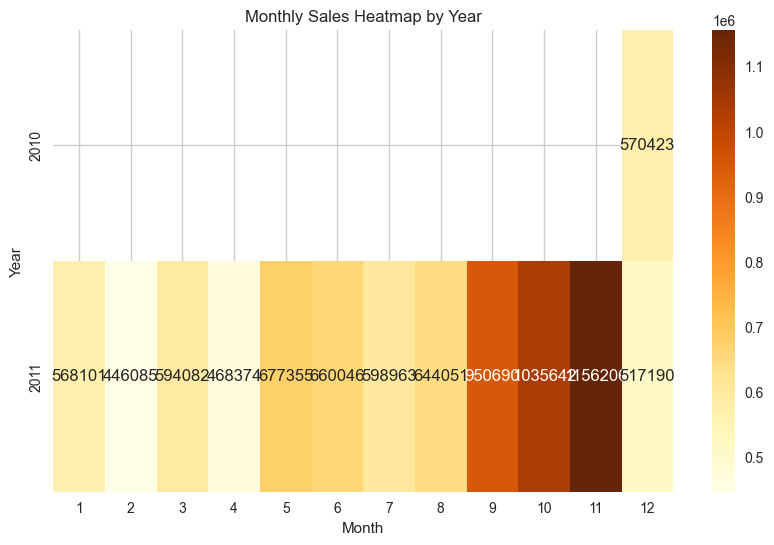

In [64]:
# Sales Heatmap — Year vs Month

# Pivot table of sales by year and month
heatmap_data = df_clean.pivot_table(values='TotalValue', index='InvoiceYear', columns='month', aggfunc='sum')

plt.figure(figsize=(10, 6))
sns.heatmap(heatmap_data, annot=True, fmt=".0f", cmap="YlOrBr")
plt.title("Monthly Sales Heatmap by Year")
plt.xlabel("Month")
plt.ylabel("Year")
plt.show()


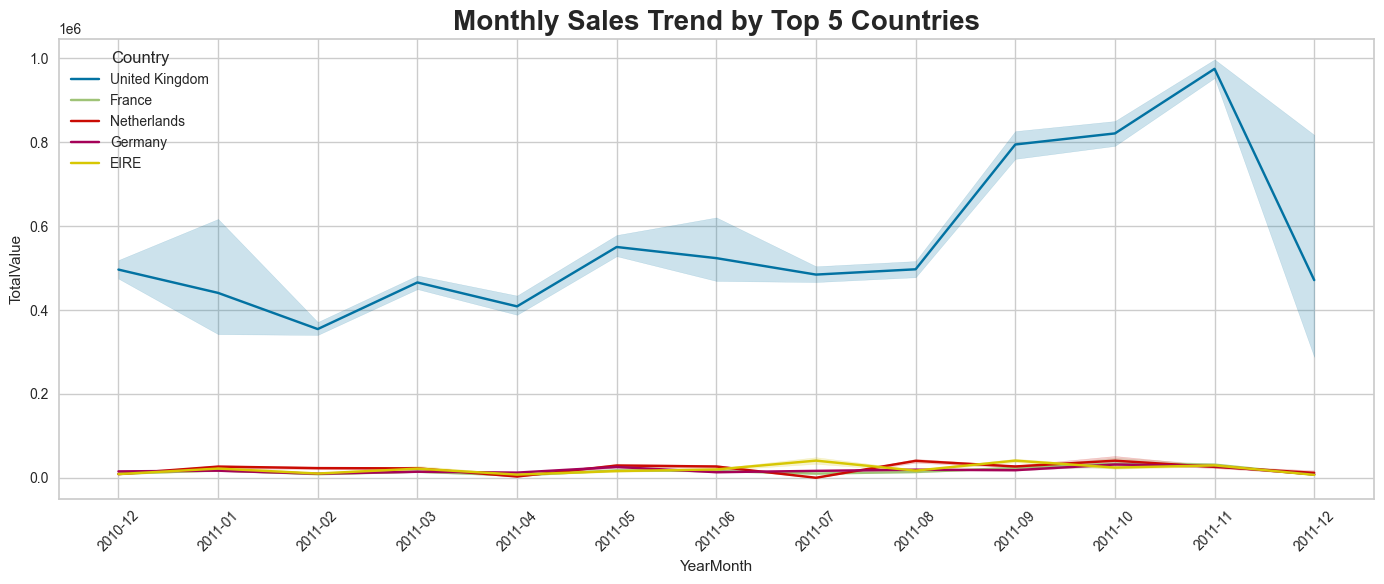

In [65]:
# Monthly Breakdown by Country

# Top 5 countries by total sales
top_countries = df_clean.groupby('Country')['TotalValue'].sum().sort_values(ascending=False).head(5).index

df_clean_top = df_clean[df_clean['Country'].isin(top_countries)]

# Plot total sales by month for each top country
plt.figure(figsize=(14, 6))
sns.lineplot(data=df_clean_top, x='YearMonth', y='TotalValue', hue='Country', estimator='sum')
plt.title("Monthly Sales Trend by Top 5 Countries", fontsize=20, fontweight='bold')
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig('Monthly Sales by Top 5 Countries.png', dpi=300, bbox_inches='tight')
plt.show()

C:\Users\Shaney\AppData\Local\Temp\ipykernel_11048\2443250579.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=time_trend.values, y=time_trend.index, palette='icefire')


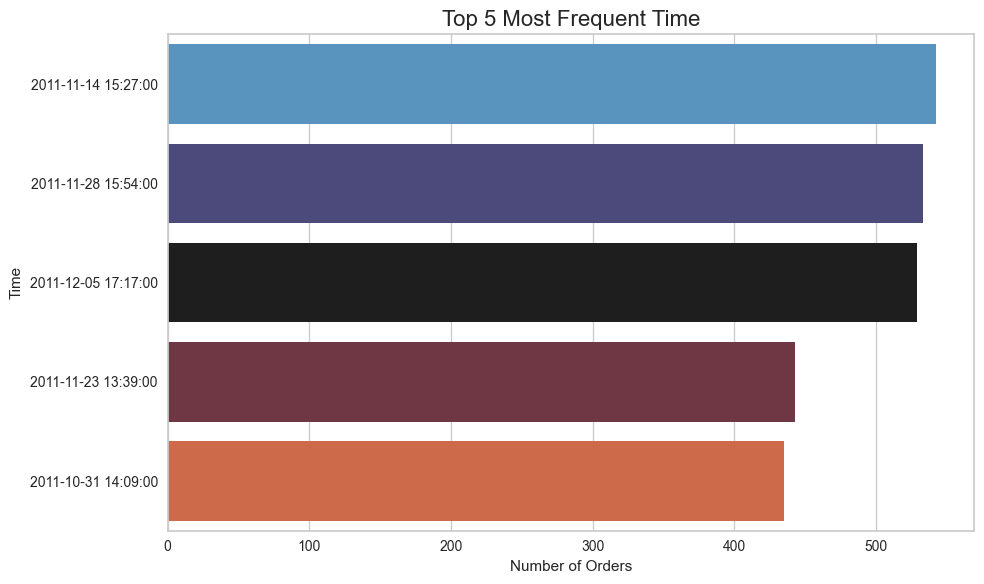

In [66]:
# Most frequent timings
time_trend = df_clean['InvoiceDate'].value_counts().head(5)

plt.figure(figsize=(10, 6))
sns.barplot(x=time_trend.values, y=time_trend.index, palette='icefire')
plt.title('Top 5 Most Frequent Time', fontsize=16)
plt.xlabel('Number of Orders')
plt.ylabel('Time')

plt.tight_layout()
plt.savefig('Top5_Time.png', dpi=300, bbox_inches='tight')
plt.show()

- Popular order placing timings appear to be between 1.39pm to 5.17pm.
- Promotions can be targeted at these time periods (e.g. from 1.30pm to 2.30pm, and 3.30pm to 5.30pm) to boost additional cart sales during payment processing.

C:\Users\Shaney\AppData\Local\Temp\ipykernel_11048\3850296929.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=description_count.values, y=description_count.index, palette='icefire')


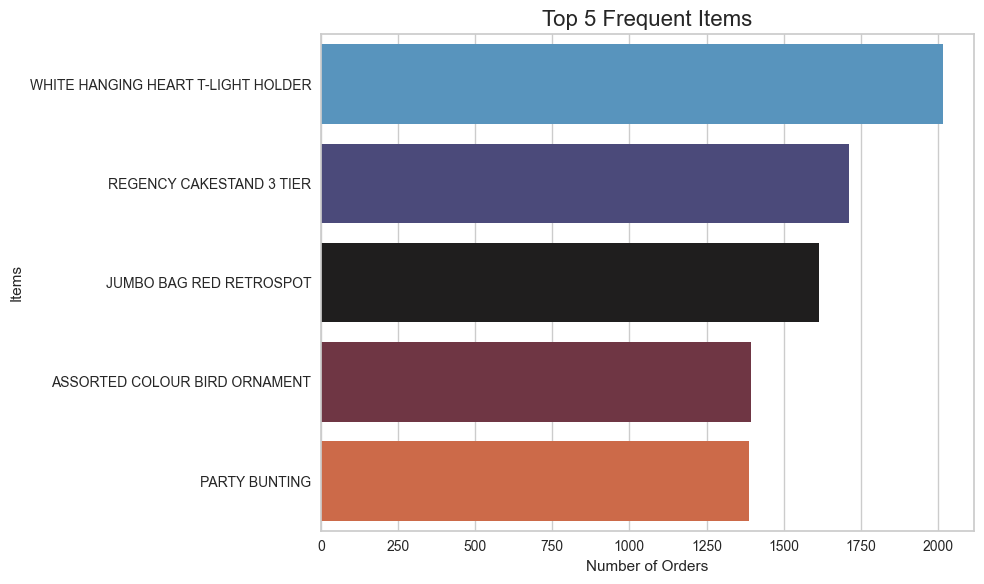

In [68]:
# Most purchased products
description_count = df_clean["Description"].value_counts().head(5)

plt.figure(figsize=(10, 6))
sns.barplot(x=description_count.values, y=description_count.index, palette='icefire')
plt.title("Top 5 Frequent Items", fontsize=16)
plt.xlabel("Number of Orders")
plt.ylabel("Items")

plt.tight_layout()
plt.savefig('Top5_Items.png', dpi=300, bbox_inches='tight')
plt.show()

In [69]:
df_clean['Country'].value_counts()

Country
United Kingdom          349203
Germany                   9025
France                    8326
EIRE                      7226
Spain                     2479
Netherlands               2359
Belgium                   2031
Switzerland               1841
Portugal                  1453
Australia                 1181
Norway                    1071
Italy                      758
Channel Islands            747
Finland                    685
Cyprus                     603
Sweden                     450
Austria                    398
Denmark                    380
Poland                     330
Japan                      321
Israel                     245
Unspecified                241
Singapore                  222
Iceland                    182
USA                        179
Canada                     151
Greece                     145
Malta                      112
United Arab Emirates        68
European Community          60
RSA                         57
Lebanon                     45


In [70]:
# Proportion of transactions in each Country
df_clean['Country'].value_counts(normalize=True).sort_values(ascending=False).to_frame()

,proportion
Country,
United Kingdom,0.889254
Germany,0.022982
France,0.021202
EIRE,0.018401
Spain,0.006313
Netherlands,0.006007
Belgium,0.005172
Switzerland,0.004688
Portugal,0.003700


In [71]:
# Proportion of transactions by country (normalized count)
transaction_proportion = (
    df_clean['Country'].value_counts(normalize=True)
    .sort_values(ascending=False)
    .to_frame(name='Proportion')
)

transaction_proportion.head()

,Proportion
Country,
United Kingdom,0.889254
Germany,0.022982
France,0.021202
EIRE,0.018401
Spain,0.006313


In [72]:
df['Country'].nunique()

38

Insights:
- There are 38 countries in the portfolio.
- United Kingdom covers 89% of entire portfolio.

In [74]:
monthly_volume = df_clean['YearMonth'].value_counts().sort_index().to_frame('Count').reset_index().rename(columns={'index': 'Value'})
monthly_volume

,YearMonth,Count
0,2010-12,25670
1,2011-01,20988
2,2011-02,19706
3,2011-03,26870
4,2011-04,22433
5,2011-05,28073
6,2011-06,26926
7,2011-07,26580
8,2011-08,26790
9,2011-09,39669


<Axes: xlabel='YearMonth', ylabel='Count'>

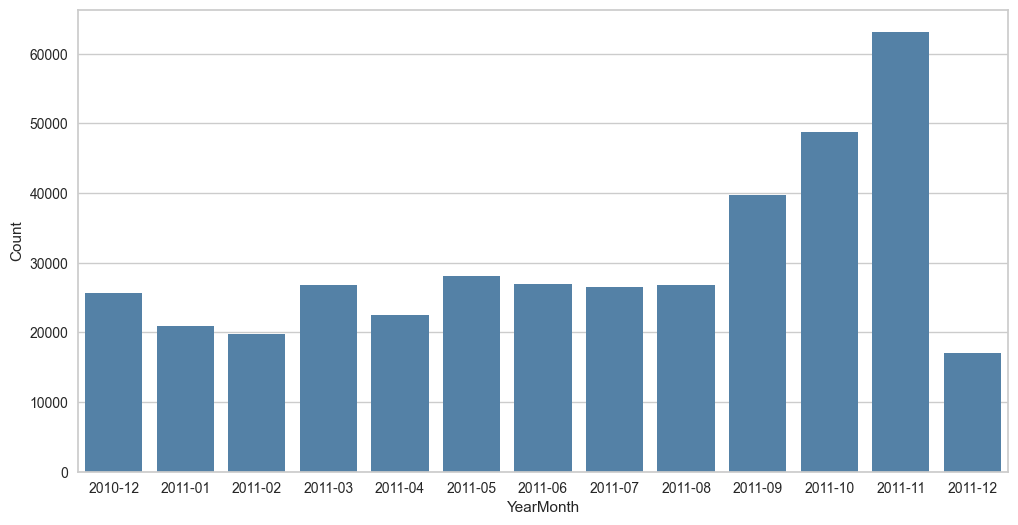

In [75]:
plt.figure(figsize=(12,6))
sns.barplot(x=monthly_volume['YearMonth'], y=monthly_volume['Count'],color='steelblue')

- Increase of transactions observed in the months 2011-09 to 2011-11.
- This is based on each line items (total number of orders of each product on each invoices).

In [77]:
df_clean.groupby('YearMonth').nunique().sort_index()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,InvoiceYear,TotalValue,day_name,month_name,month,day
YearMonth,,,,,,,,,,,,,,
2010-12,1400,2411,2418,105,1293,134,885,22,1,853,6,1,1,20
2011-01,987,2121,2118,93,942,130,741,20,1,808,6,1,1,24
2011-02,997,2124,2122,90,966,117,758,24,1,763,6,1,1,24
2011-03,1321,2234,2240,101,1269,145,974,22,1,863,6,1,1,27
2011-04,1149,2217,2225,98,1080,144,856,24,1,853,6,1,1,21
2011-05,1555,2219,2255,106,1436,166,1056,20,1,951,6,1,1,25
2011-06,1393,2339,2361,114,1315,157,991,24,1,1029,6,1,1,26
2011-07,1331,2351,2373,103,1254,155,949,24,1,991,6,1,1,26
2011-08,1280,2356,2386,118,1210,151,935,23,1,982,6,1,1,26


- Increase of stock transactions from 2011-09 to 2011-11 mainly due to the increase numbers of customers.

In [79]:
# Monthly Transaction Volume
monthly_volume = (
    df_clean.groupby('YearMonth')['InvoiceNo']
    .nunique()
    .reset_index()
    .rename(columns={'InvoiceNo': 'TransactionCount'})
)

# Monthly Revenue
monthly_revenue = (
    df_clean.groupby('YearMonth')['TotalValue']
    .sum()
    .reset_index()
    .rename(columns={'TotalValue': 'MonthlyRevenue'})
)

# Merge both for combined plotting
monthly_summary = pd.merge(monthly_volume, monthly_revenue, on='YearMonth')


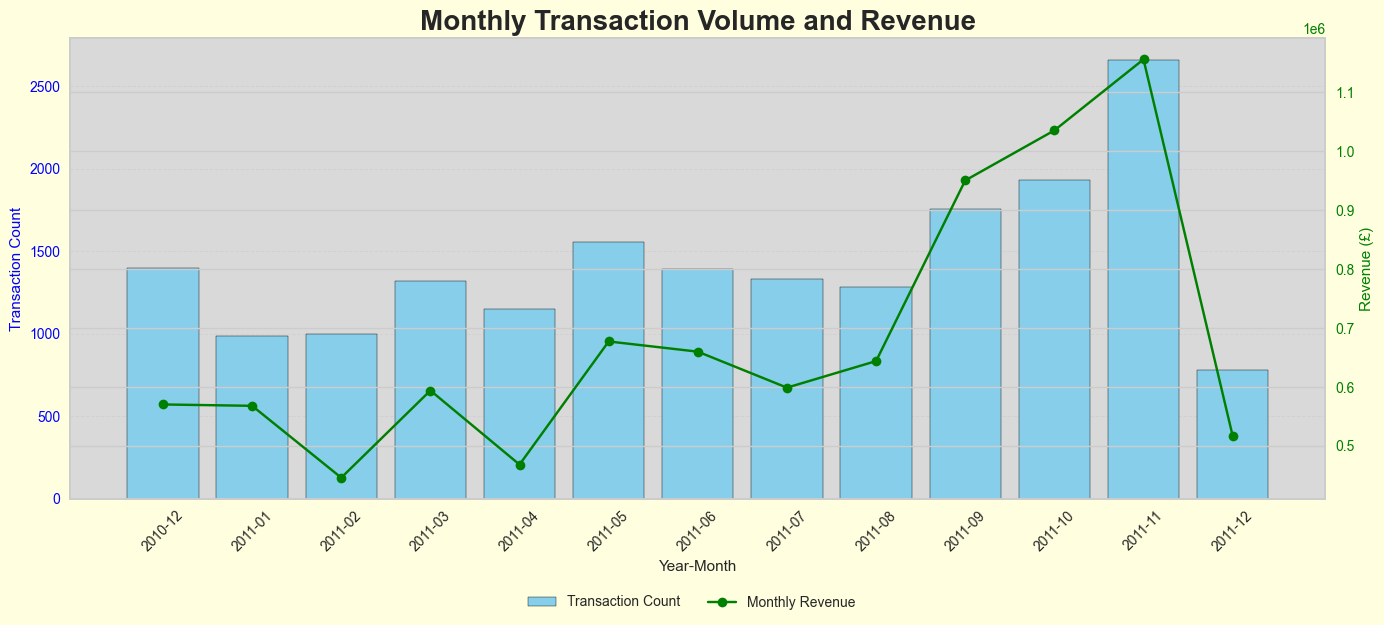

In [80]:
# Plot with only horizontal grid lines
fig, ax1 = plt.subplots(figsize=(14, 6))

# Set background colors
ax1.set_facecolor('#d9d9d9')             # Inner grey background
fig.patch.set_facecolor('lightyellow')   # Outer background

# Bar plot for transaction count
bars = ax1.bar(monthly_summary['YearMonth'], monthly_summary['TransactionCount'],
               color='skyblue', label='Transaction Count', edgecolor='black')
ax1.set_xlabel('Year-Month')
ax1.set_ylabel('Transaction Count', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.set_xticks(range(len(monthly_summary['YearMonth'])))
ax1.set_xticklabels(monthly_summary['YearMonth'], rotation=45)

# Enable only horizontal grid lines
ax1.grid(True, axis='y', linestyle='--', linewidth=0.7, alpha=0.6)
ax1.grid(False, axis='x')

# Line plot for revenue (secondary axis)
ax2 = ax1.twinx()
line = ax2.plot(monthly_summary['YearMonth'], monthly_summary['MonthlyRevenue'],
                color='green', label='Monthly Revenue', marker='o')
ax2.set_ylabel('Revenue (£)', color='green')
ax2.tick_params(axis='y', labelcolor='green')

# Title and layout
plt.title('Monthly Transaction Volume and Revenue', fontsize=20, fontweight='bold')

# Combined legend below the chart
lines_labels = [ax.get_legend_handles_labels() for ax in [ax1, ax2]]
lines, labels = [sum(lol, []) for lol in zip(*lines_labels)]
fig.legend(lines, labels, loc='lower center', ncol=2, bbox_to_anchor=(0.5, -0.05))

plt.tight_layout()
plt.savefig('Monthly Transaction Volume and Revenue.png', dpi=300, bbox_inches='tight')
plt.show()

- This is based on unique invoices. Number of transactions (invoices) in each month.
- Significant increase in sales from 2011-08 to 2011-11.
- Could be due to shoppings for Christmas season.
- It appears that this is the period of the year having the highest sales traffic, the rest of the months fluctuates around the same level.
- Feb/Apr generated the lowest sales revenue even though with comparable transaction volumes. -> Can promote cross selling, pairing upon checkout. Increase chances of more items bought together with each transaction.
- Sharp drop from 2011-11 to 2011-12 probably due to most shoppers already done their Xmas shopping in Nov, Dec could be the remaining doing their last minute Xmas shoppping. -> can throw in some last min sales promo 

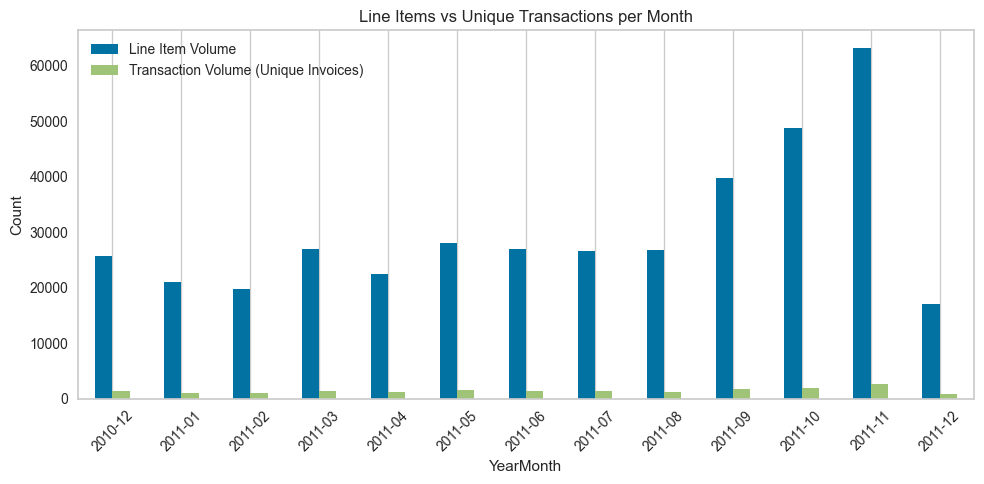

,YearMonth,Line Item Volume,Transaction Volume (Unique Invoices)
0,2010-12,25670,1400
1,2011-01,20988,987
2,2011-02,19706,997
3,2011-03,26870,1321
4,2011-04,22433,1149
5,2011-05,28073,1555
6,2011-06,26926,1393
7,2011-07,26580,1331
8,2011-08,26790,1280
9,2011-09,39669,1755


In [82]:
# Compute metrics
monthly_line_items = df_clean.groupby('YearMonth').size()
monthly_transactions = df_clean.groupby('YearMonth')['InvoiceNo'].nunique()

# Combine into a DataFrame
comparison_df = pd.DataFrame({
    'Line Item Volume': monthly_line_items,
    'Transaction Volume (Unique Invoices)': monthly_transactions
})

# Plot
comparison_df.plot(kind='bar', figsize=(10, 5), title='Line Items vs Unique Transactions per Month')
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.grid(axis='y')
plt.show()

comparison_df.reset_index()

Here’s a clear comparison between:

1. Line Item Volume: Counts every individual line in invoices (e.g., 3 items in the same invoice = 3 line items).

2. Transaction Volume (Unique Invoices): Counts each unique invoice once, regardless of how many items it contains.

✅ So, depending on your definition:

1. Sales volume by line items = “how many items sold” (used in demand analysis).

2. Sales volume by invoice = “how many transactions happened” (used in transaction frequency analysis).

Both are valid—just use the one that matches your business question.

For my business use case (customer segmentation using RFM analysis based on behavioral patterns), the more relevant measure is transaction volume, not line item volume. Here's why:

1. ✅ Transaction Volume (InvoiceNo - unique count)
- Reflects how often a customer shops (Frequency).
- Aligned with the idea of a single purchase event.
- Tells you how engaged or loyal a customer is over time.
- Best fit for the “F” in RFM: how many times a customer bought, not how many products.

2. ⚠️ Line Item Volume (number of rows in dataset per customer)
- Counts every product in a transaction.
- Can inflate Frequency for customers who purchase many small items at once.
- More useful for inventory or product-level analysis, not customer segmentation.

3. 📌 Summary for my Case:
- Use nunique(InvoiceNo) when you want to measure how frequently a customer shops.
- Use len(x) (line items) only if you're analyzing product-level behavior, not RFM.

In [85]:
# Top 5 countries based on total sales revenue
top_5_countries = df_clean.groupby('Country')['TotalValue'].sum().sort_values(ascending=False).head(5)
top_5_countries

Country
United Kingdom    7285024.644
Netherlands        285446.340
EIRE               265262.460
Germany            228678.400
France             208934.310
Name: TotalValue, dtype: float64

Insights:
1. UK Dominates Sales (88% among Top 5 Countries)
- The United Kingdom contributes the majority of sales, making it the primary focus for customer care and retention strategies.
- Ensuring high customer satisfaction and loyalty in the UK should be a priority.

2. Expansion Strategy
- For future growth, expanding sales in other countries is essential.
- Instead of starting from scratch, we can leverage existing markets.
- Germany, France, and EIRE (ranked 2nd to 4th) should be our initial expansion targets, as they already have a customer base.

## 3. Feature Engineering for RFM
- Recency: Number of days since the last purchase.
- Frequency: Number of purchases.
- Monetary: Total spend (Quantity * UnitPrice).

### Compute RFM Table

In [89]:
# Find the last (most recent) date in the dataset's InvoiceDate column
last_date = df_clean['InvoiceDate'].max()
print("Last invoice date in dataset:", last_date)

Last invoice date in dataset: 2011-12-09 12:50:00


In [90]:
import datetime as dt

# Set anchorDate to one day after the last transaction date
anchorDate = last_date + dt.timedelta(days=1)

print("Anchor date set to:", anchorDate)

Anchor date set to: 2011-12-10 12:50:00


In [91]:
# Calculate RFM
rfm = df_clean.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (anchorDate - x.max()).days,   # Recency (days since last purchase)
    'InvoiceNo': lambda x: x.nunique(),                     # Frequency (number of unique transactions)
    'TotalValue': lambda x: x.sum()                         # Monetary (total revenue)
}).reset_index()

rfm.columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary']

In [92]:
# Count unique countries per customer
country_counts = df_clean.groupby('CustomerID')['Country'].nunique()

# Check how many customers have more than one country
multi_country_customers = country_counts[country_counts > 1]

# Display how many such customers exist
print(f"Customers with multiple countries: {len(multi_country_customers)}")

Customers with multiple countries: 8


In [93]:
# Assign most frequent country per customer
customer_country = (
    df_clean.groupby(['CustomerID', 'Country'])
    .size()
    .reset_index(name='count')
    .sort_values(['CustomerID', 'count'], ascending=[True, False])
    .drop_duplicates('CustomerID')
    .set_index('CustomerID')['Country']
)

# Merge into your RFM table
rfm = rfm.set_index('CustomerID')
rfm['Country'] = customer_country
rfm = rfm.reset_index()

In [94]:
rfm.head()

,CustomerID,Recency,Frequency,Monetary,Country
0,12346.0,326,1,77183.60,United Kingdom
1,12347.0,2,7,4310.00,Iceland
2,12348.0,75,4,1797.24,Finland
3,12349.0,19,1,1757.55,Italy
4,12350.0,310,1,334.40,Norway


In [95]:
rfm['Country'].value_counts(normalize=True)

Country
United Kingdom          0.903642
Germany                 0.021669
France                  0.020055
Spain                   0.006685
Belgium                 0.005533
Switzerland             0.004610
Portugal                0.004380
Italy                   0.003227
Finland                 0.002766
Norway                  0.002305
Netherlands             0.002075
Austria                 0.002075
Channel Islands         0.002075
Australia               0.002075
Sweden                  0.001844
Japan                   0.001844
Denmark                 0.001844
Cyprus                  0.001383
Poland                  0.001383
USA                     0.000922
Canada                  0.000922
Greece                  0.000922
Unspecified             0.000922
Israel                  0.000692
EIRE                    0.000692
United Arab Emirates    0.000461
Bahrain                 0.000461
Malta                   0.000461
Saudi Arabia            0.000231
Singapore               0.000231
Ic

In [96]:
df_clean.groupby('CustomerID')['InvoiceNo'].nunique().to_frame()

,InvoiceNo
CustomerID,
12346.0,1
12347.0,7
12348.0,4
12349.0,1
12350.0,1
...,...
18280.0,1
18281.0,1
18282.0,2


In [97]:
df_clean.groupby('CustomerID')['InvoiceNo'].value_counts().to_frame()

count
CustomerID InvoiceNo       
12346.0    541431         1
12347.0    573511        47
           537626        31
           542237        29
           549222        24
...                     ...
18283.0    560032         1
           575675         1
18287.0    570715        38
           554065        29
           573167         3

[18532 rows x 1 columns]

In [98]:
df_clean[df_clean['CustomerID']==12347]['InvoiceNo'].to_frame()

,InvoiceNo
14938,537626
14939,537626
14940,537626
14941,537626
14942,537626
...,...
535010,581180
535011,581180
535012,581180
535013,581180


✅ Explanation:
- anchor_date is one day after the last purchase date to ensure Recency = 0 for the most recent buyer.
- x.nunique() ensures we count distinct transactions, not line items.
- This gives a more accurate customer-level summary for segmentation.

### EDA on RFM

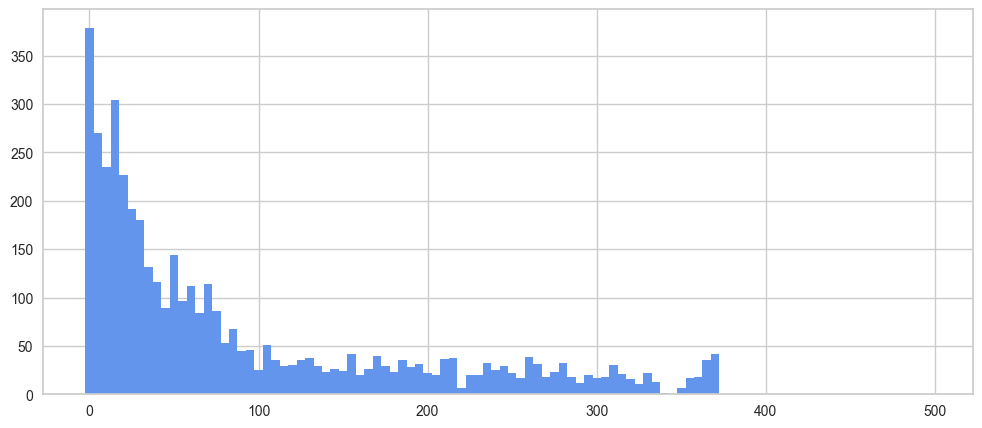

In [101]:
# Check distribution of the features
plt.figure(figsize = (12,5))
hist = plt.hist(rfm['Recency'], bins=100, range=[0,500], align='left', color='cornflowerblue')

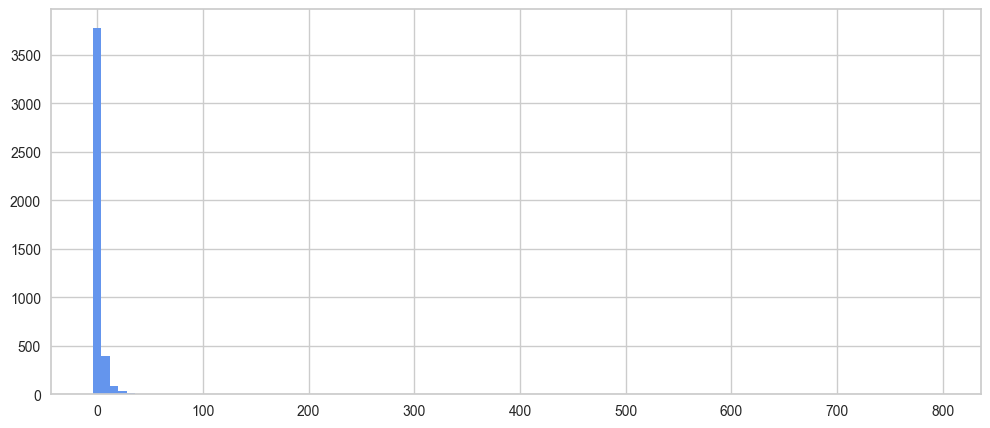

In [102]:
plt.figure(figsize = (12,5))
hist = plt.hist(rfm['Frequency'], bins=100, range=[0,800], align='left', color='cornflowerblue')

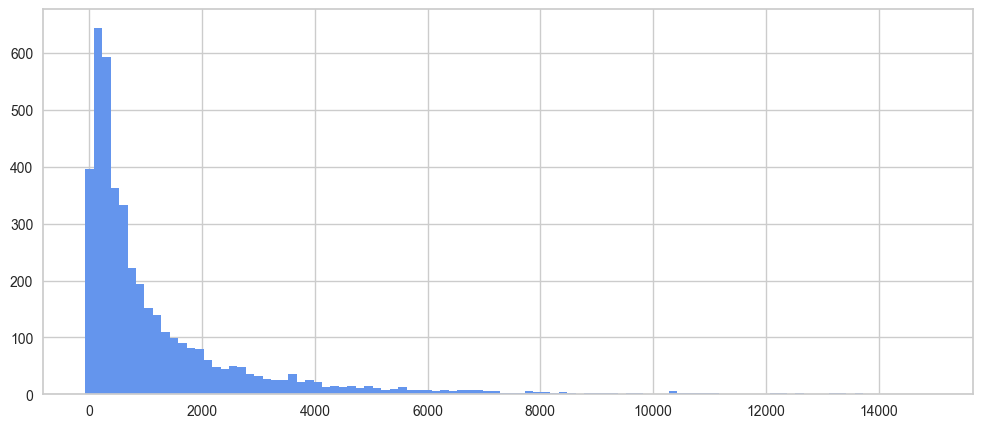

In [103]:
plt.figure(figsize = (12,5))
hist = plt.hist(rfm['Monetary'], bins=100, range=[0,15000], align='left', color='cornflowerblue')

All three features are right-skewed, with particularly large values in Frequency and Monetary. When using distance-based models such as KMeans, these large values can skew the model results, as KMeans relies on Euclidean distance. A good practice is to apply a logarithmic transformation to these features.

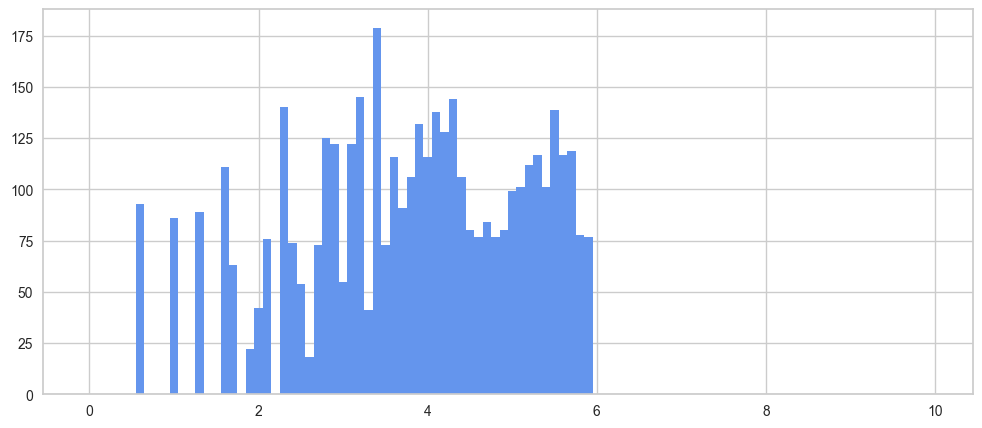

In [105]:
plt.figure(figsize = (12,5))
hist = plt.hist(np.log(rfm['Recency']+1), bins=100, range=[0,10], align='left', color='cornflowerblue')

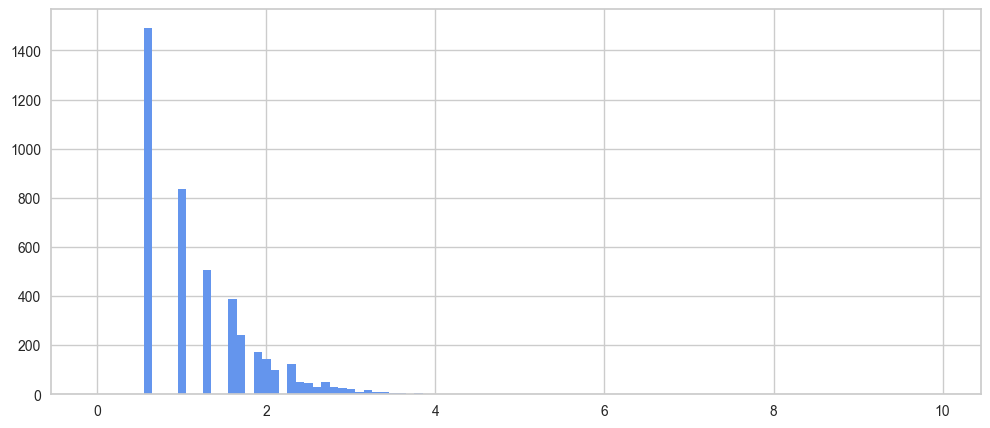

In [106]:
plt.figure(figsize = (12,5))
hist = plt.hist(np.log(rfm['Frequency']+1), bins=100, range=[0,10], align='left', color='cornflowerblue')

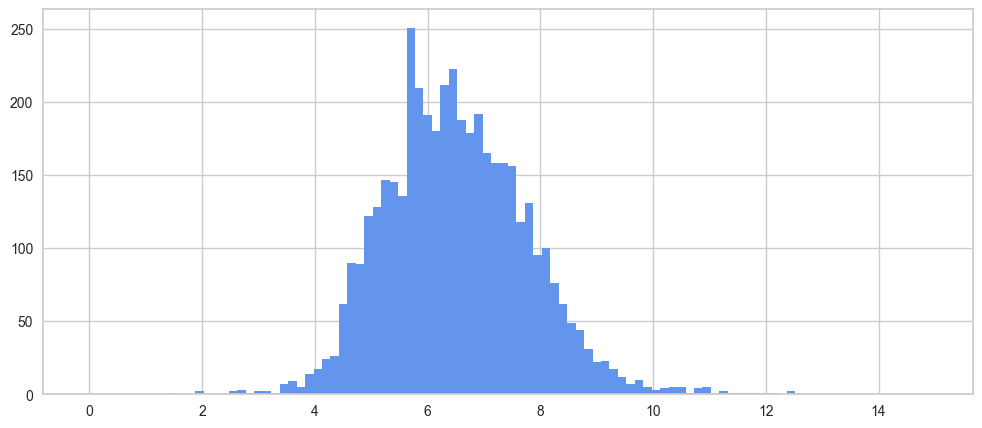

In [107]:
plt.figure(figsize = (12,5))
hist = plt.hist(np.log(rfm['Monetary']+1), bins=100, range=[0,15], align='left', color='cornflowerblue')

- After taking the logarithm, the distributions are close to normal and their scales are the same.

### Log-transform RFM values

In [110]:
# Log Transform to Reduce Skewness (Optional, but helpful for clustering)
rfm['log_Recency'] = np.log1p(rfm['Recency'])                # log(1 + Recency)
rfm['log_Frequency'] = np.log1p(rfm['Frequency'])            # log(1 + Frequency)
rfm['log_Monetary'] = np.log1p(rfm['Monetary'])              # log(1 + Monetary)

In [111]:
rfm.head()

,CustomerID,Recency,Frequency,Monetary,Country,log_Recency,log_Frequency,log_Monetary
0,12346.0,326,1,77183.60,United Kingdom,5.789960,0.693147,11.253955
1,12347.0,2,7,4310.00,Iceland,1.098612,2.079442,8.368925
2,12348.0,75,4,1797.24,Finland,4.330733,1.609438,7.494564
3,12349.0,19,1,1757.55,Italy,2.995732,0.693147,7.472245
4,12350.0,310,1,334.40,Norway,5.739793,0.693147,5.815324


In [112]:
rfm.describe()

,CustomerID,Recency,Frequency,Monetary,log_Recency,log_Frequency,log_Monetary
count,4338.000000,4338.000000,4338.000000,4338.000000,4338.000000,4338.000000,4338.000000
mean,15300.408022,92.536422,4.272015,2048.688081,3.830734,1.345582,6.588562
std,1721.808492,100.014169,7.697998,8985.230220,1.340261,0.683104,1.258438
min,12346.000000,1.000000,1.000000,3.750000,0.693147,0.693147,1.558145
25%,13813.250000,18.000000,1.000000,306.482500,2.944439,0.693147,5.728418
50%,15299.500000,51.000000,2.000000,668.570000,3.951244,1.098612,6.506636
75%,16778.750000,142.000000,5.000000,1660.597500,4.962845,1.791759,7.415535
max,18287.000000,374.000000,209.000000,280206.020000,5.926926,5.347108,12.543284


- It depends on the business scenarios to determine the number of segmentations. I will use K-Means to identify appropriate number of clusters.

## 4. Clustering - K-Means
K-Means is a centroid-based clustering algorithm that partitions data into k clusters based on their distance from the mean (centroid) of each cluster.

### Elbow Method for determining the number of clusters :

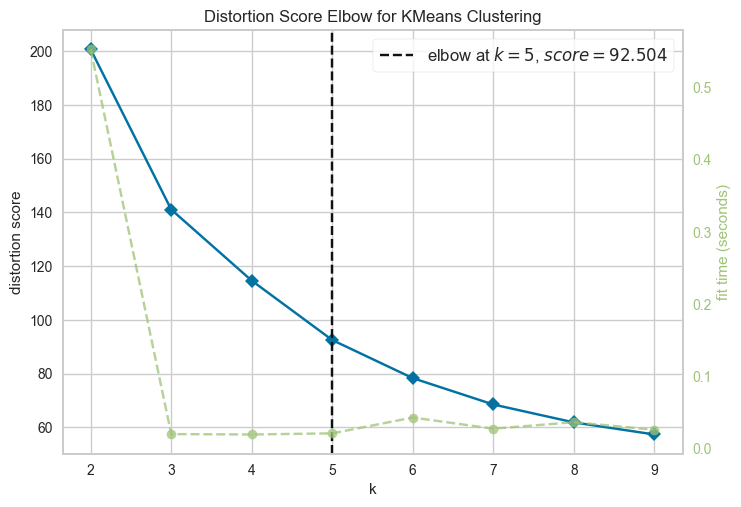

In [116]:
# Scale the Features

# Using Scaled log-transformed values (MinMax Scaler)
scaler = MinMaxScaler()
rfm_scaled = scaler.fit_transform(rfm[['log_Recency', 'log_Frequency', 'log_Monetary']])

model = KMeans(random_state=42)
visualizer = KElbowVisualizer(model, k=(2, 10))

visualizer.fit(rfm_scaled) # Fit the data to the visualizer
visualizer.show() # Finalize and render the figure
plt.show()

In [117]:
ssd =[]

K = range(2, 12)

for k in K:
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(rfm_scaled)
    ssd.append(model.inertia_)
    print(f'Silhouette Score for {k} clusters (MinMax scaled log values): {silhouette_score(rfm_scaled, model.labels_):.4f}')

Silhouette Score for 2 clusters (MinMax scaled log values): 0.4486
Silhouette Score for 3 clusters (MinMax scaled log values): 0.3699
Silhouette Score for 4 clusters (MinMax scaled log values): 0.3668
Silhouette Score for 5 clusters (MinMax scaled log values): 0.3595
Silhouette Score for 6 clusters (MinMax scaled log values): 0.3532
Silhouette Score for 7 clusters (MinMax scaled log values): 0.3468
Silhouette Score for 8 clusters (MinMax scaled log values): 0.3338
Silhouette Score for 9 clusters (MinMax scaled log values): 0.3238
Silhouette Score for 10 clusters (MinMax scaled log values): 0.3186
Silhouette Score for 11 clusters (MinMax scaled log values): 0.3194


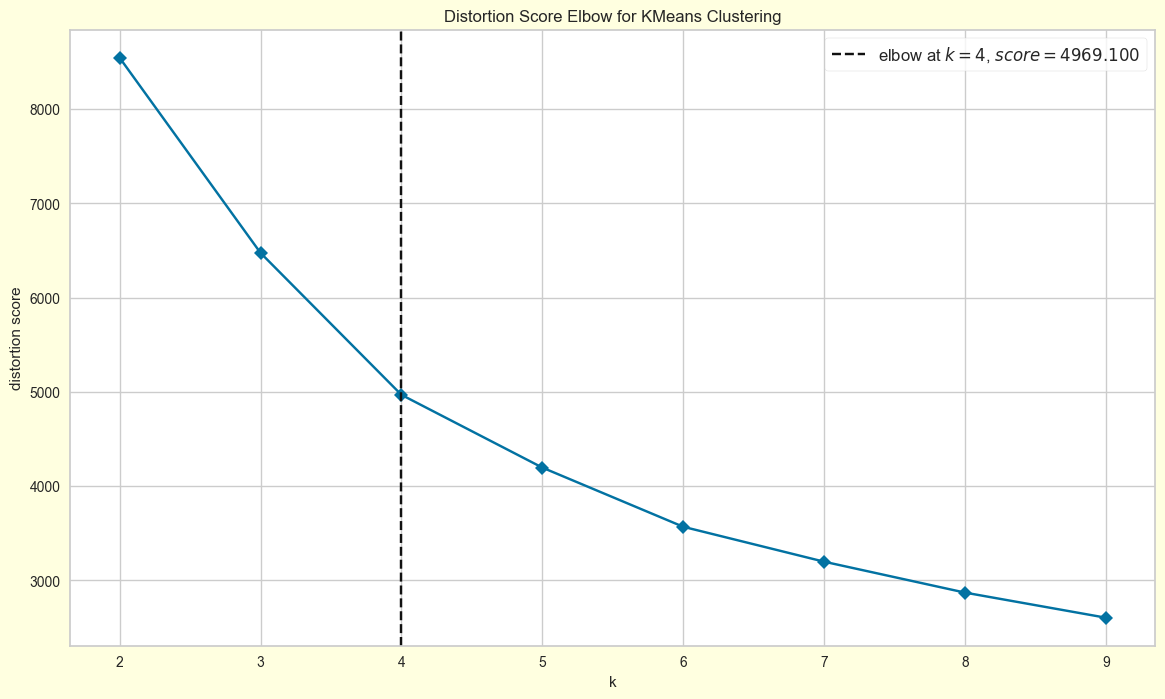

In [118]:
# Without scaling (only use log-transformed values)
df_rfm=np.array(rfm.loc[:,['log_Recency','log_Frequency','log_Monetary']])

plt.rcParams['figure.facecolor'] = 'lightyellow'
model = KMeans(random_state=42)
visualizer = KElbowVisualizer(model, k=(2, 10), timings=False)

plt.figure(figsize=(14, 8))
visualizer.fit(df_rfm) # Fit the data to the visualizer
visualizer.show() # Finalize and render the figure
plt.show()

In [119]:
ssd =[]

K = range(2, 12)

for k in K:
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(df_rfm)
    ssd.append(model.inertia_)
    print(f'Silhouette Score for {k} clusters (log values ony, no scaling): {silhouette_score(df_rfm, model.labels_):.4f}')

Silhouette Score for 2 clusters (log values ony, no scaling): 0.4173
Silhouette Score for 3 clusters (log values ony, no scaling): 0.3266
Silhouette Score for 4 clusters (log values ony, no scaling): 0.3485
Silhouette Score for 5 clusters (log values ony, no scaling): 0.3344
Silhouette Score for 6 clusters (log values ony, no scaling): 0.3231
Silhouette Score for 7 clusters (log values ony, no scaling): 0.3167
Silhouette Score for 8 clusters (log values ony, no scaling): 0.3174
Silhouette Score for 9 clusters (log values ony, no scaling): 0.3091
Silhouette Score for 10 clusters (log values ony, no scaling): 0.3018
Silhouette Score for 11 clusters (log values ony, no scaling): 0.2926


- It seems clustering with log-transformed values alone without scaling gave comparable results.
- 4-clusters is also easier for the stakeholder to comprehend.
- Given the customer size is only 4338, splitting into too many clusters (more than 4), may not be beneficial as some clusters would have small size. 

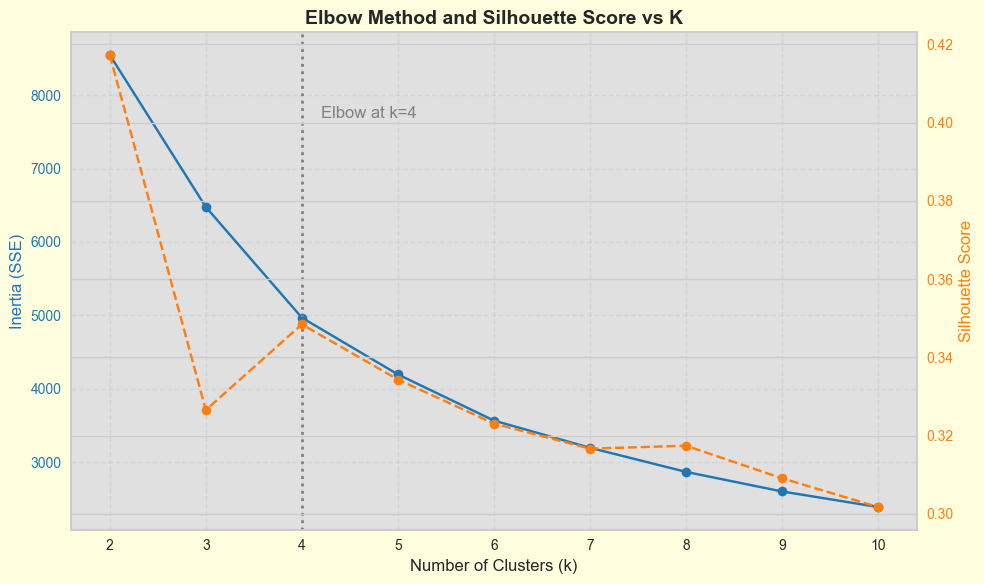

In [121]:
# Calculate inertia and silhouette scores
inertias = []
silhouettes = []
K = range(2, 11)

for k in K:
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(df_rfm)
    inertias.append(model.inertia_)
    silhouettes.append(silhouette_score(df_rfm, model.labels_))

# Elbow point (you can change this based on visual inspection)
elbow_k = 4

# Create plot with updated backgrounds
fig, ax1 = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor('lightyellow')   # Outer background
ax1.set_facecolor('#e0e0e0')             # Slightly darker grey inner plot background

# Inertia (SSE) curve
color = 'tab:blue'
ax1.set_xlabel('Number of Clusters (k)', fontsize=12)
ax1.set_ylabel('Inertia (SSE)', color=color, fontsize=12)
ax1.plot(K, inertias, marker='o', color=color, label='Inertia (SSE)')
ax1.tick_params(axis='y', labelcolor=color)

# Dotted vertical line at elbow
ax1.axvline(x=elbow_k, color='gray', linestyle=':', linewidth=2)
ax1.text(elbow_k + 0.2, max(inertias) * 0.9, f'Elbow at k={elbow_k}', color='gray')

# Silhouette Score curve on secondary Y-axis
ax2 = ax1.twinx()
color = 'tab:orange'
ax2.set_ylabel('Silhouette Score', color=color, fontsize=12)
ax2.plot(K, silhouettes, marker='o', linestyle='--', color=color, label='Silhouette Score')
ax2.tick_params(axis='y', labelcolor=color)

# Title and layout
plt.title('Elbow Method and Silhouette Score vs K', fontsize=14, fontweight='bold')
ax1.grid(True, linestyle='--', alpha=0.6)
fig.tight_layout()

# Save and show
plt.savefig('elbow_silhouette_plot.png', dpi=300, bbox_inches='tight')
plt.show()

✅ How to Interpret

1. Inertia (SSE): Look for the "elbow" point where SSE stops dropping significantly.

2. Silhouette Score: Higher is better (closer to +1 means tighter, well-separated clusters).

👉 The best k is usually:

    - At the elbow of the inertia curve
    - Where silhouette score is also relatively high

### ✅ Selected 4 clusters with K-MEANS

In [124]:
# Assign Cluster Labels to Customers
# After choosing k=4, fit the model and add the cluster labels to RFM data:

# Fit model with optimal k
kmeans = KMeans(n_clusters=4, random_state=42)
rfm['Cluster'] = kmeans.fit_predict(df_rfm)  # chosen feature set

In [125]:
rfm.head()

,CustomerID,Recency,Frequency,Monetary,Country,log_Recency,log_Frequency,log_Monetary,Cluster
0,12346.0,326,1,77183.60,United Kingdom,5.789960,0.693147,11.253955,2
1,12347.0,2,7,4310.00,Iceland,1.098612,2.079442,8.368925,3
2,12348.0,75,4,1797.24,Finland,4.330733,1.609438,7.494564,2
3,12349.0,19,1,1757.55,Italy,2.995732,0.693147,7.472245,2
4,12350.0,310,1,334.40,Norway,5.739793,0.693147,5.815324,1


In [126]:
# Profile the Clusters
# Group by cluster and calculate mean of RFM metrics:

cluster_summary = rfm.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean',
    'Cluster': 'count'  # Number of customers in each
}).rename(columns={'Cluster': 'Num_Customers'}).round(1)

cluster_summary

,Recency,Frequency,Monetary,Num_Customers
Cluster,,,,
0,22.5,2.1,466.4,931
1,196.7,1.4,321.5,1456
2,74.5,4.1,1871.7,1163
3,9.5,12.4,7370.7,788


In [127]:
# Group by cluster and calculate mean of Log-RFM metrics:

cluster_summary2 = rfm.groupby('Cluster').agg({
    'log_Recency': 'mean',
    'log_Frequency': 'mean',
    'log_Monetary': 'mean',
    'Cluster': 'count'  # Number of customers in each
}).rename(columns={'Cluster': 'Num_Customers'}).round(1)

cluster_summary2

,log_Recency,log_Frequency,log_Monetary,Num_Customers
Cluster,,,,
0,2.9,1.1,6.0,931
1,5.1,0.8,5.6,1456
2,4.1,1.5,7.3,1163
3,2.1,2.3,8.2,788


In [128]:
# Overall RFM averages
overall_avg = rfm[['Recency', 'Frequency', 'Monetary']].mean()

# Label values as High/Low
def label_value(value, average, lower_is_better=False):
    if lower_is_better:
        return 'Low' if value < average else 'High'
    else:
        return 'High' if value > average else 'Low'

# Apply the labeling
cluster_summary['Recency_Level'] = cluster_summary['Recency'].apply(lambda x: label_value(x, overall_avg['Recency'], lower_is_better=True))
cluster_summary['Frequency_Level'] = cluster_summary['Frequency'].apply(lambda x: label_value(x, overall_avg['Frequency']))
cluster_summary['Monetary_Level'] = cluster_summary['Monetary'].apply(lambda x: label_value(x, overall_avg['Monetary']))

# Define business actions based on RFM levels
def suggest_action(row):
    if row['Recency_Level'] == 'Low' and row['Frequency_Level'] == 'High' and row['Monetary_Level'] == 'High':
        return 'Reward VIPs with loyalty programs'
    elif row['Recency_Level'] == 'High' and row['Frequency_Level'] == 'Low':
        return 'Re-engage with win-back offers'
    elif row['Recency_Level'] == 'Low' and row['Frequency_Level'] == 'Low':
        return 'Upsell to new or occasional buyers'
    elif row['Recency_Level'] == 'High':
        return 'Target with reactivation campaigns'
    else:
        return 'Monitor and nurture'

cluster_summary['Action'] = cluster_summary.apply(suggest_action, axis=1)

# Display final summary
cluster_summary

,Recency,Frequency,Monetary,Num_Customers,Recency_Level,Frequency_Level,Monetary_Level,Action
Cluster,,,,,,,,
0,22.5,2.1,466.4,931,Low,Low,Low,Upsell to new or occasional buyers
1,196.7,1.4,321.5,1456,High,Low,Low,Re-engage with win-back offers
2,74.5,4.1,1871.7,1163,Low,Low,Low,Upsell to new or occasional buyers
3,9.5,12.4,7370.7,788,Low,High,High,Reward VIPs with loyalty programs


In [129]:
overall_avg.to_frame()

,0
Recency,92.536422
Frequency,4.272015
Monetary,2048.688081


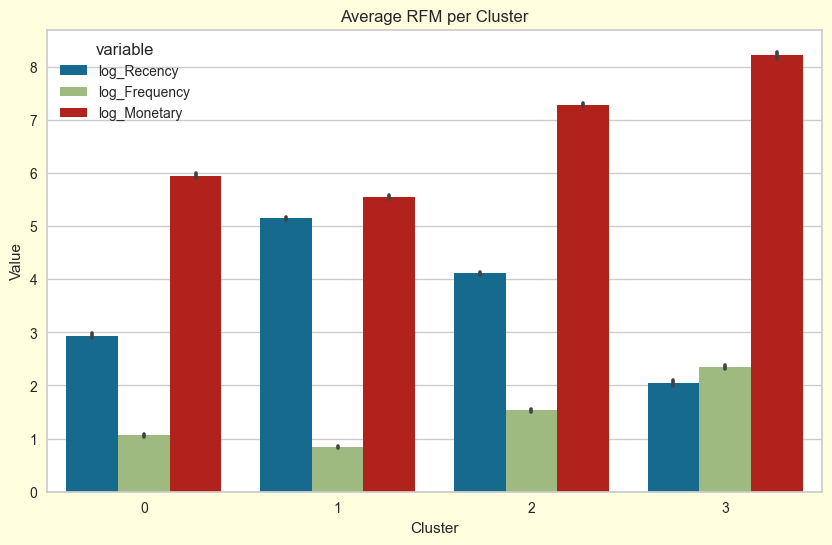

In [130]:
# 📊 Visualize the Cluster Profiles

# a. Bar Plot – RFM per Cluster
rfm_melt = rfm.melt(id_vars='Cluster', value_vars=['log_Recency', 'log_Frequency', 'log_Monetary'])

plt.figure(figsize=(10,6))
sns.barplot(data=rfm_melt, x='Cluster', y='value', hue='variable')
plt.title('Average RFM per Cluster')
plt.ylabel('Value')
plt.show()


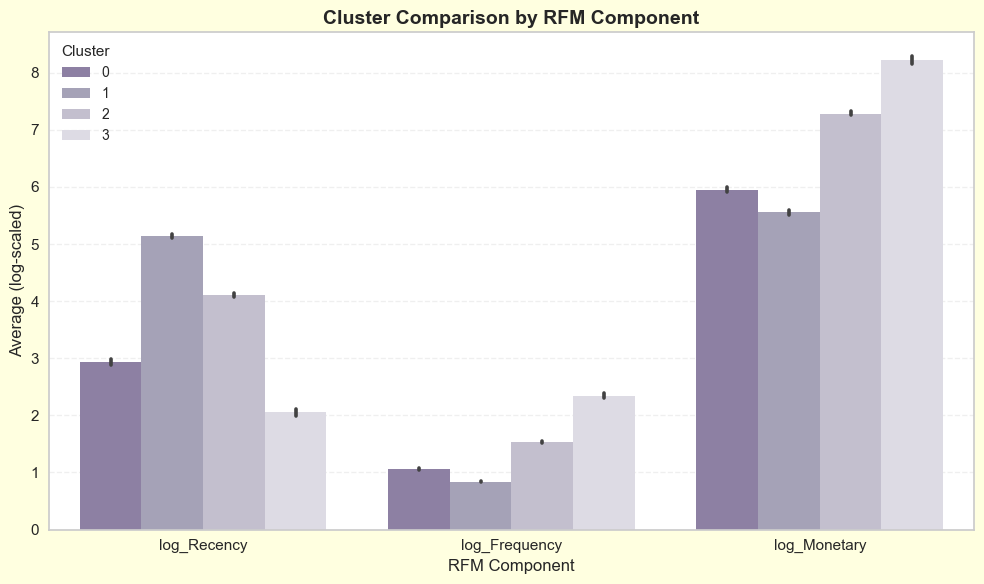

In [131]:
# Melt for barplot (RFM on x-axis, Clusters as hue)
rfm_melt = rfm.melt(id_vars='Cluster', 
                    value_vars=['log_Recency', 'log_Frequency', 'log_Monetary'],
                    var_name='RFM', value_name='Value')

# Custom color palette to match your presentation (grey/purple theme)
theme_palette = ['#8C7AA9', '#A29EBB', '#C2BCD1', '#DCD9E6']  # Adjust for your number of clusters

plt.figure(figsize=(10,6))
sns.barplot(data=rfm_melt, x='RFM', y='Value', hue='Cluster', palette=theme_palette)

plt.title('Cluster Comparison by RFM Component', fontsize=14, weight='bold')
plt.xlabel('RFM Component', fontsize=12)
plt.ylabel('Average (log-scaled)', fontsize=12)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.legend(title='Cluster', title_fontsize=11, fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

In [132]:
# Group by cluster and compute average metrics
cluster_profile = rfm.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean',
    'CustomerID': 'count'
}).rename(columns={'CustomerID': 'CustomerCount'}).round(1)

cluster_profile['AvgOrderValue'] = cluster_profile['Monetary'] / cluster_profile['Frequency']
cluster_profile = cluster_profile.sort_values(by='Monetary', ascending=False)

display(cluster_profile)

,Recency,Frequency,Monetary,CustomerCount,AvgOrderValue
Cluster,,,,,
3,9.5,12.4,7370.7,788,594.411290
2,74.5,4.1,1871.7,1163,456.512195
0,22.5,2.1,466.4,931,222.095238
1,196.7,1.4,321.5,1456,229.642857


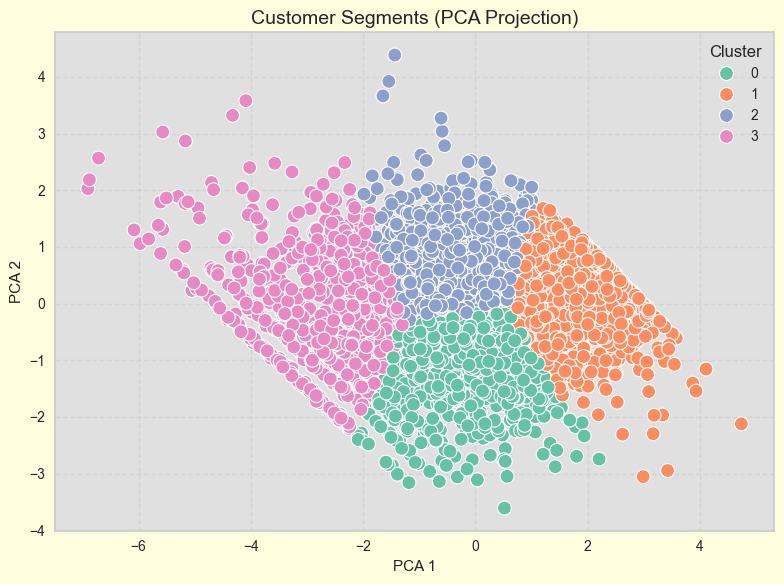

In [133]:
# Apply PCA
pca = PCA(n_components=2)
pca_features = pca.fit_transform(df_rfm)

# Create plot
fig, ax = plt.subplots(figsize=(8, 6))
fig.patch.set_facecolor('lightyellow')     # Optional: outer background (like before)
ax.set_facecolor('#e0e0e0')                # Inner plot background: slightly darker grey

# Scatter plot with clusters
sns.scatterplot(
    x=pca_features[:, 0],
    y=pca_features[:, 1],
    hue=rfm['Cluster'],
    palette='Set2',
    s=100,
    ax=ax
)

# Labels and title
ax.set_title('Customer Segments (PCA Projection)', fontsize=14)
ax.set_xlabel('PCA 1')
ax.set_ylabel('PCA 2')
ax.grid(True, linestyle='--', alpha=0.6)

# Save and show
plt.tight_layout()
plt.savefig('pca_clusters_plot.png', dpi=300, bbox_inches='tight')
plt.show()

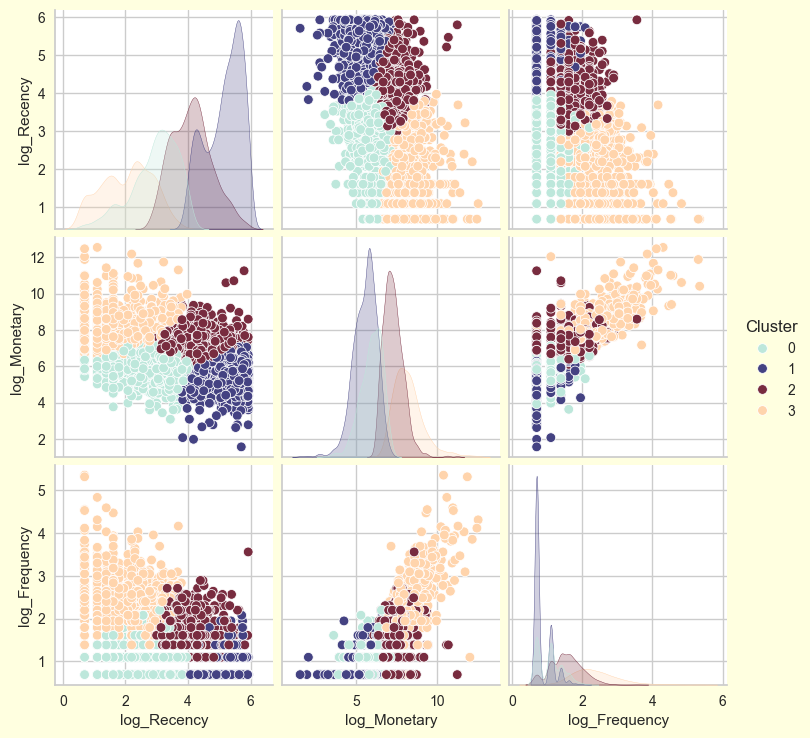

In [134]:
# Creating a pairplot to visualize the distribution and relationships between selected features.
sns.pairplot(rfm, hue='Cluster', vars=['log_Recency', 'log_Monetary', 'log_Frequency'], palette='icefire')
plt.show()

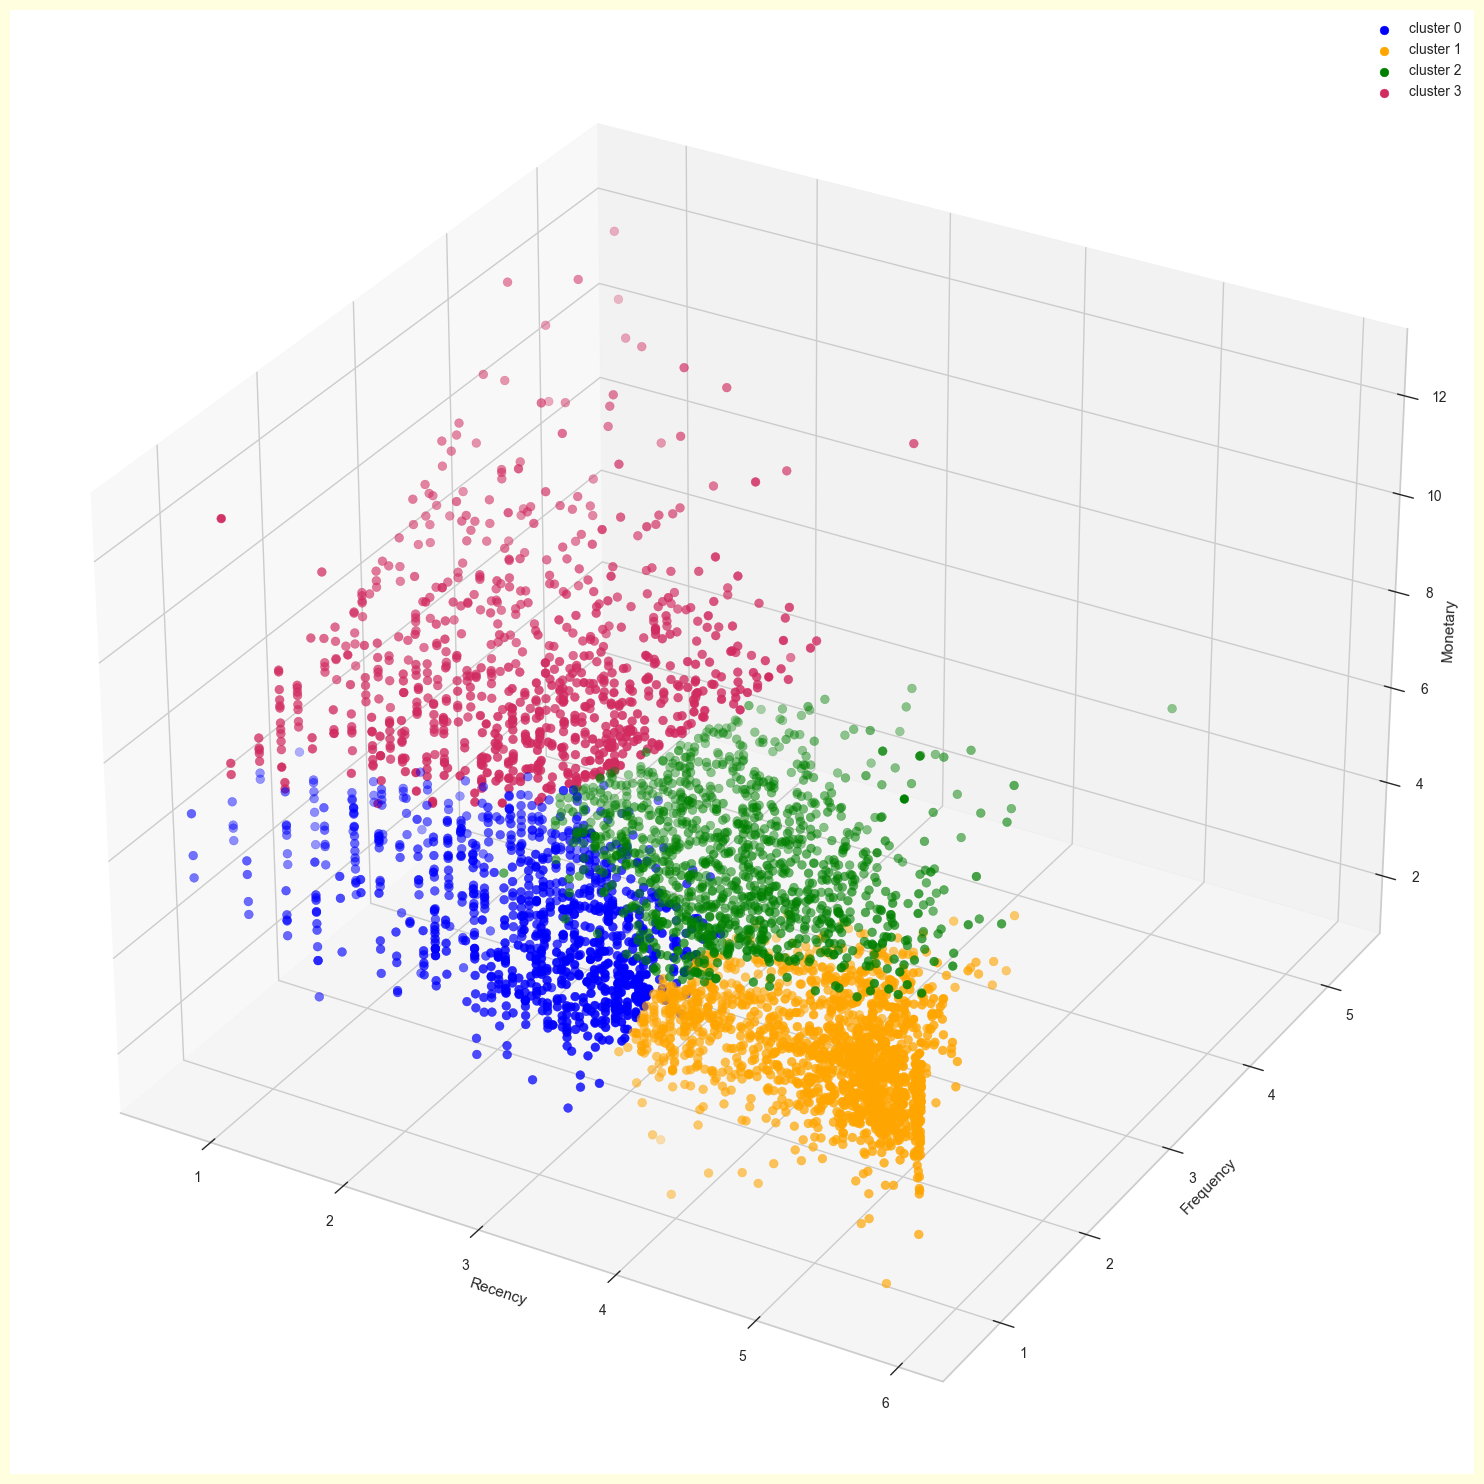

In [135]:
# kmeans = KMeans(n_clusters=4, random_state=42)

km = kmeans.fit_predict(df_rfm)

fig = plt.figure(figsize = (15,15))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(df_rfm[km == 0,0],df_rfm[km == 0,1],df_rfm[km == 0,2], s = 40 , color = 'blue', label = "cluster 0")
ax.scatter(df_rfm[km == 1,0],df_rfm[km == 1,1],df_rfm[km == 1,2], s = 40 , color = 'orange', label = "cluster 1")
ax.scatter(df_rfm[km == 2,0],df_rfm[km == 2,1],df_rfm[km == 2,2], s = 40 , color = 'green', label = "cluster 2")
ax.scatter(df_rfm[km == 3,0],df_rfm[km == 3,1],df_rfm[km == 3,2], s = 40 , color = '#D12B60', label = "cluster 3")
ax.set_xlabel('Recency')
ax.set_ylabel('Frequency')
ax.set_zlabel('Monetary')
ax.legend()

# Save and show plot
plt.tight_layout()
plt.savefig("kmeans_3d_clusters.png", dpi=300, bbox_inches='tight')
plt.show()

In [136]:
# Creating an interactive 3D plot.
import plotly.graph_objects as go

colors = ['blue', 'orange', 'green', '#D12B60']

# Create a 3D scatter plot
fig = go.Figure()
fig.add_trace(go.Scatter3d(x=df_rfm[km == 0,0], y=df_rfm[km == 0,1], z=df_rfm[km == 0,2], 
                           mode='markers', marker=dict(color=colors[0], size=5, opacity=0.4), name='Cluster 0'))
fig.add_trace(go.Scatter3d(x=df_rfm[km == 1,0], y=df_rfm[km == 1,1], z=df_rfm[km == 1,2], 
                           mode='markers', marker=dict(color=colors[1], size=5, opacity=0.4), name='Cluster 1'))
fig.add_trace(go.Scatter3d(x=df_rfm[km == 2,0], y=df_rfm[km == 2,1], z=df_rfm[km == 2,2],
                           mode='markers', marker=dict(color=colors[2], size=5, opacity=0.4), name='Cluster 2'))
fig.add_trace(go.Scatter3d(x=df_rfm[km == 3,0], y=df_rfm[km == 3,1], z=df_rfm[km == 3,2],
                           mode='markers', marker=dict(color=colors[3], size=5, opacity=0.4), name='Cluster 3'))

fig.update_layout(
    title=dict(text='3D Visualization of Customer Clusters', x=0.5),
    scene=dict(
        xaxis=dict(backgroundcolor="#fcf0dc", gridcolor='white', title='Recency'),
        yaxis=dict(backgroundcolor="#fcf0dc", gridcolor='white', title='Frequency'),
        zaxis=dict(backgroundcolor="#fcf0dc", gridcolor='white', title='Monetary'),
    ),
    width=900,
    height=800
)
fig.show()

#### Radar Charts for RFM Clusters
Show each cluster’s RFM profile as a spider chart.

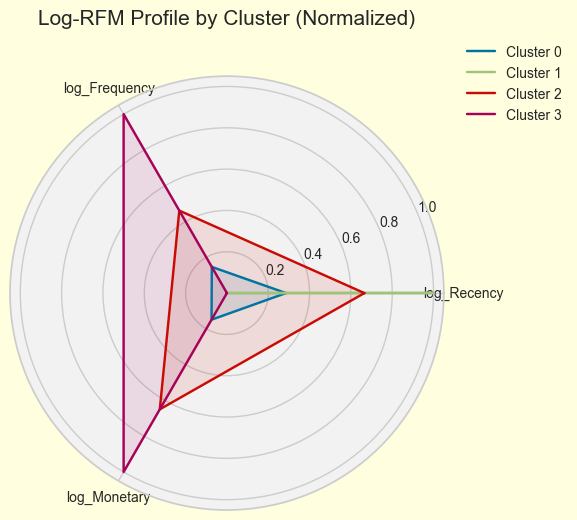

In [138]:
# ✅ Step 1: Group by Cluster on Log RFM
log_cluster_avg = rfm.groupby('Cluster')[['log_Recency', 'log_Frequency', 'log_Monetary']].mean()

# Normalize for radar plot
scaler = MinMaxScaler()
log_cluster_scaled = pd.DataFrame(
    scaler.fit_transform(log_cluster_avg),
    index=log_cluster_avg.index,
    columns=log_cluster_avg.columns
)

# ✅ Step 2: Radar Chart Function with Grey Inner Plot
def plot_radar_log(df, title):
    labels = df.columns
    num_vars = len(labels)
    angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
    angles += angles[:1]  # complete the loop

    fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))

    # Grey inner background
    ax.set_facecolor('#f2f2f2')  # light grey

    for i, row in df.iterrows():
        values = row.tolist()
        values += values[:1]
        ax.plot(angles, values, label=f'Cluster {i}')
        ax.fill(angles, values, alpha=0.1)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(['log_Recency', 'log_Frequency', 'log_Monetary'])
    ax.set_title(title, size=15, y=1.1)
    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))

    # ✅ Save to file
    plt.tight_layout()
    plt.savefig('radar_plot_log.png', dpi=300, bbox_inches='tight')
    plt.show()

# ✅ Step 3: Plot and Save the Chart
plot_radar_log(log_cluster_scaled, 'Log-RFM Profile by Cluster (Normalized)')

### Cluster Analysis & Interpretation
- To create customer segments using the RFM + K-Means:

`1. Cluster 0 – Recent Low-Mid Value Buyers:`
- Recency: 22.5 days
- Frequency: 2.1
- Monetary: $466
- % of Customers: 21.5%

    - Interpretation:
        - Recent buyers who’ve only purchased a couple of times and spend moderately.
    - Business Action:
        - Welcome/loyalty nurture campaigns
        - Push subscription or bundle offers to increase frequency

`2. Cluster 1 – At-Risk / Low Value:`
- Recency: 196.7 days (long ago)
- Frequency: 1.4
- Monetary: $321
- % of Customers: 33.5%

    - Interpretation:
        - Most inactive and low-spending customers. Possibly churned.
    - Business Action:
        - Re-engagement emails or win-back offers
        - A/B test discounts to trigger another order
        - Or exclude from paid marketing

`3. Cluster 2 – Potential Loyalists / High Spenders:`
- Recency: 74.5 days
- Frequency: 4.1
- Monetary: $1,872
- % of Customers: 26.8%

    - Interpretation:
        - Valuable customers with good spending and frequency, but not as recent.
    - Business Action:
        - Send targeted reactivation campaigns
        - Offer personalized recommendations to increase recency
        - Incentivize next purchase (e.g., discounts or points)

`4. Cluster 3 – VIP Customers (Loyal High-Value):`
- Recency: 9.5 days (very recent)
- Frequency: 12.4 (very frequent)
- Monetary: $7,370 (highest spenders)
- % of Customers: 18.2% (788 / 4338)

    - Interpretation:
        - Your best customers. They buy often, recently, and spend a lot.
    - Business Action:
        - Prioritize retention with loyalty programs, VIP perks
        - Offer exclusive products or early access
        - Consider upselling premium bundles

**🎯Customer Segmentation Overview:**

| Segment                             | % of Customers |Avg Order Value   | Key Traits                           | Strategic Action                      |
| ----------------------------------- | :--------------: | :----------------: |------------------------------------ | :-------------------------------------: |
| **Cluster 3 – VIPs**                | **18%**            | **\$594**        | Frequent, recent, high spend         | Loyalty rewards, VIP perks            |
| **Cluster 2 – High Potential**      | **27%**            | **\$456**        | Moderate recency, good spend but less frequent | Target with special deals or personalized content |
| **Cluster 0 – New/Moderate Buyers** | **21%**            | **\$222**        | Recent, low frequency, low-mid spend | Nurture campaigns, upsell             |
| **Cluster 1 – At-Risk**             | **34%**            | **\$230**        | Inactive, low frequency, low spend   | Win-back or exclude from targeting    |


| Cluster | Recency | Frequency | Monetary | % of Customers | Avg Order Value | Interpretation                                                                    |
| ------- | ------- | --------- | -------- | -------------- | --------------- | --------------------------------------------------------------------------------- |
| **3**   | 9.5     | 12.4      | 7,370.7  | 18.2%          | **\$594**       | **Elite VIPs** – recent, frequent, and high-value purchases. Most profitable.     |
| **2**   | 74.5    | 4.1       | 1,871.7  | 26.8%          | **\$456**       | **High-Value Infrequents** – spend well, less frequent, slightly older purchases. |
| **0**   | 22.5    | 2.1       | 466.4    | 21.5%          | **\$222**       | **New/Lukewarm Buyers** – recent, low frequency and spend. Potential to grow.     |
| **1**   | 196.7   | 1.4       | 321.5    | 33.5%          | **\$230**       | **Low-Value Dormants** – old, infrequent, low-spending. Possibly churned.         |


## 6. CLV Prediction - Regression Models

Additional Features Can be Added to X as input variables to the models.

Here are the additional engineered features:

|Feature Name|	Code Suggestion|
|-------------|-----------------|
|TotalQuantity|	df.groupby('CustomerID')['Quantity'].sum()|
|AvgQuantityPerOrder|	TotalQuantity / Frequency|
|Tenure	Days| between first and last purchase|

In [146]:
# Expand RFM Table (for Regression)

# Total Quantity per customer
qty = df_clean.groupby('CustomerID')['Quantity'].sum().reset_index(name='TotalQuantity')

# Tenure: Days between first and last purchase
tenure = df_clean.groupby('CustomerID').agg(
    FirstPurchase=('InvoiceDate', 'min'),
    LastPurchase=('InvoiceDate', 'max')
).reset_index()
tenure['Tenure'] = (tenure['LastPurchase'] - tenure['FirstPurchase']).dt.days

# Average Order Value
rfm['AvgOrderValue'] = rfm['Monetary'] / rfm['Frequency']

# Merge additional features into RFM
rfm = rfm.merge(qty, on='CustomerID', how='left')
rfm = rfm.merge(tenure[['CustomerID', 'Tenure']], on='CustomerID', how='left')

# Average Quantity per Order
rfm['AvgQuantityPerOrder'] = rfm['TotalQuantity'] / rfm['Frequency']

In [147]:
rfm.head()

,CustomerID,Recency,Frequency,Monetary,Country,log_Recency,log_Frequency,log_Monetary,Cluster,AvgOrderValue,TotalQuantity,Tenure,AvgQuantityPerOrder
0,12346.0,326,1,77183.60,United Kingdom,5.789960,0.693147,11.253955,2,77183.600000,74215,0,74215.000000
1,12347.0,2,7,4310.00,Iceland,1.098612,2.079442,8.368925,3,615.714286,2458,365,351.142857
2,12348.0,75,4,1797.24,Finland,4.330733,1.609438,7.494564,2,449.310000,2341,282,585.250000
3,12349.0,19,1,1757.55,Italy,2.995732,0.693147,7.472245,2,1757.550000,631,0,631.000000
4,12350.0,310,1,334.40,Norway,5.739793,0.693147,5.815324,1,334.400000,197,0,197.000000


In [148]:
# Define features and target
X = rfm[['Recency', 'Frequency', 'TotalQuantity', 'AvgQuantityPerOrder', 'Tenure']]
y = rfm['Monetary']    # Use this as a proxy for CLV

In [149]:
# Split into train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### 1. Import and Train All Three Models

In [294]:
# Models
lr = LinearRegression()
rf = RandomForestRegressor(n_estimators=50, random_state=22)
xgb = XGBRegressor( n_estimators=50,       # much higher than 5
                    learning_rate=0.01,     # lower = better generalization
                    max_depth=20,            # can experiment with 4–7
                    # subsample=0.5,          # randomly sample rows to reduce overfitting
                    # colsample_bytree=0.5,   # randomly sample features)
                  )
                   
# Fit models
lr.fit(X_train, y_train)
rf.fit(X_train, y_train)
xgb.fit(X_train, y_train)

# Predict
y_pred_lr = lr.predict(X_test)
y_pred_rf = rf.predict(X_test)
y_pred_xgb = xgb.predict(X_test)

### 2. Evaluate and Store Metrics

In [295]:
# Store metrics in a list of dictionaries
results = [
    {
        "Model": "Linear Regression",
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred_lr)),
        "R2": r2_score(y_test, y_pred_lr)
    },
    {
        "Model": "Random Forest",
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred_rf)),
        "R2": r2_score(y_test, y_pred_rf)
    },
    {
        "Model": "XGBoost",
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred_xgb)),
        "R2": r2_score(y_test, y_pred_xgb)
    }
]

results_df = pd.DataFrame(results)
print(results_df)

               Model         RMSE        R2
0  Linear Regression  5713.690743  0.680946
1      Random Forest  5428.893722  0.711960
2            XGBoost  7750.968725  0.412859


### 3. Plot: Actual vs Predicted (Side-by-Side)

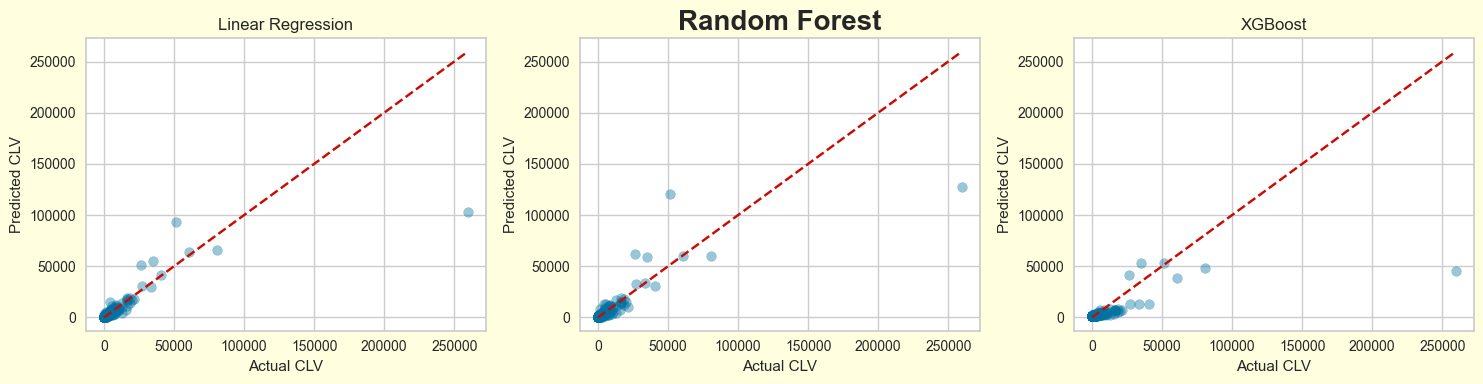

In [155]:
plt.figure(figsize=(15, 4))

# Linear Regression
plt.subplot(1, 3, 1)
plt.scatter(y_test, y_pred_lr, alpha=0.4)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.title('Linear Regression')
plt.xlabel('Actual CLV')
plt.ylabel('Predicted CLV')

# Random Forest
plt.subplot(1, 3, 2)
plt.scatter(y_test, y_pred_rf, alpha=0.4)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.title('Random Forest', fontsize=20, fontweight='bold')
plt.xlabel('Actual CLV')
plt.ylabel('Predicted CLV')

# XGBoost
plt.subplot(1, 3, 3)
plt.scatter(y_test, y_pred_xgb, alpha=0.4)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.title('XGBoost')
plt.xlabel('Actual CLV')
plt.ylabel('Predicted CLV')

plt.tight_layout()
plt.savefig('regressions_models.png', dpi=300, bbox_inches='tight')
plt.show()

### 4. Plot: RMSE & R² Comparison

In [157]:
# # Bar plot of RMSE and R2
# fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# # RMSE Plot
# sns.barplot(x='Model', y='RMSE', data=results_df, ax=ax[0])
# ax[0].set_title('Model Comparison - RMSE')

# # R² Plot
# sns.barplot(x='Model', y='R2', data=results_df, ax=ax[1])
# ax[1].set_title('Model Comparison - R² Score')

# plt.tight_layout()
# plt.savefig('RMSE vs R2.png', dpi=300, bbox_inches='tight')
# plt.show()

C:\Users\Shaney\AppData\Local\Temp\ipykernel_11048\1906084655.py:30: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

C:\Users\Shaney\AppData\Local\Temp\ipykernel_11048\1906084655.py:30: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



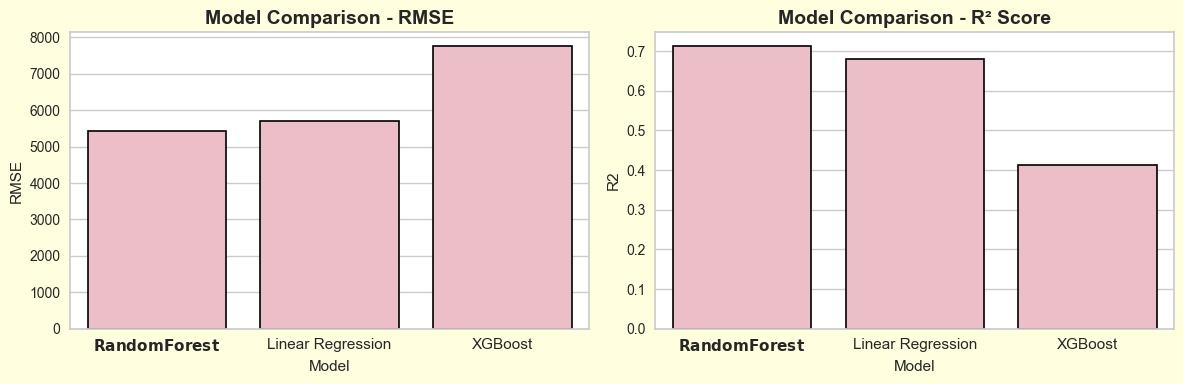

In [158]:
# Define pastel pink
pastel_pink = '#f4b6c2'

# Sort dataframes for plotting
rmse_sorted = results_df.sort_values('RMSE', ascending=True)
r2_sorted = results_df.sort_values('R2', ascending=False)

# Bar plot of RMSE and R²
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# RMSE Plot (ascending)
sns.barplot(x='Model', y='RMSE', data=rmse_sorted, ax=ax[0],
            color=pastel_pink, edgecolor='black', linewidth=1.2)
ax[0].set_title('Model Comparison - RMSE', fontsize=14, fontweight='bold')

# R² Plot (descending)
sns.barplot(x='Model', y='R2', data=r2_sorted, ax=ax[1],
            color=pastel_pink, edgecolor='black', linewidth=1.2)
ax[1].set_title('Model Comparison - R² Score', fontsize=14, fontweight='bold')

# Bold and enlarge "Random Forest" x-label on both plots
for axis in ax:
    labels = [label.get_text() for label in axis.get_xticklabels()]
    new_labels = []
    for label in labels:
        if label.lower() == 'random forest':
            new_labels.append(f"$\\bf{{{label}}}$")
        else:
            new_labels.append(label)
    axis.set_xticklabels(new_labels, fontsize=11)

plt.tight_layout()
plt.savefig('RMSE_vs_R2_sorted.png', dpi=300, bbox_inches='tight')
plt.show()


- Model performance was evaluated using RMSE for interpretability in original units and R² to assess the proportion of variance explained by the model.
- Other metrics like MAE or MAPE were not used, as RMSE and R² provided sufficient insight for model comparison in this context.

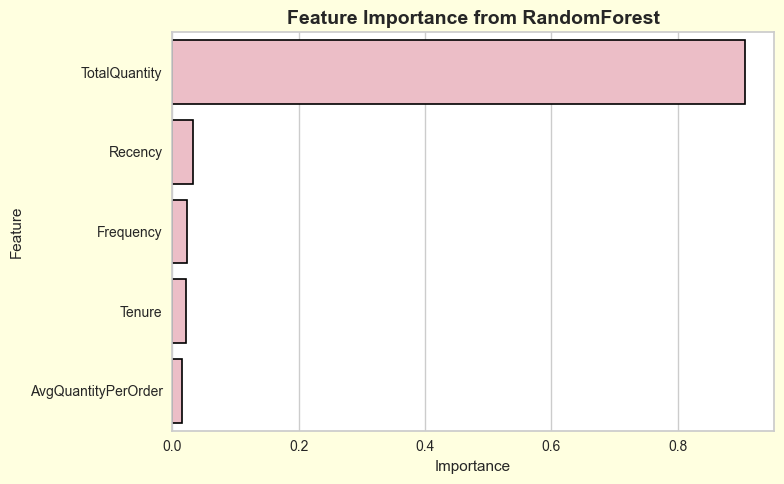

In [160]:
# Define pastel pink color
pastel_pink = '#f4b6c2'

# Get feature importance
importances = rf.feature_importances_
features = X.columns
importance_df = pd.DataFrame({'Feature': features, 'Importance': importances})
importance_df.sort_values(by='Importance', ascending=False, inplace=True)

# Plot
plt.figure(figsize=(8, 5))
sns.barplot(x='Importance', y='Feature', data=importance_df,
            color=pastel_pink, edgecolor='black', linewidth=1.2)
plt.title('Feature Importance from RandomForest', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('Rf_feature importance.png', dpi=300, bbox_inches='tight')
plt.show()

- RandomForest outperformed other models with the best RMSE and R²
- K-Means segments reveal actionable patterns for marketing

#### Business Recommendations:
- Personalize retention strategies for high-value clusters
- Launch reactivation campaigns for inactive but high-potential customers
- Use the CLV model to prioritize marketing spend and forecast revenue

## 6. Visualization of Segments / Additional EDAs
- Use bar plots, boxplots, or heatmaps to visualize the segments.

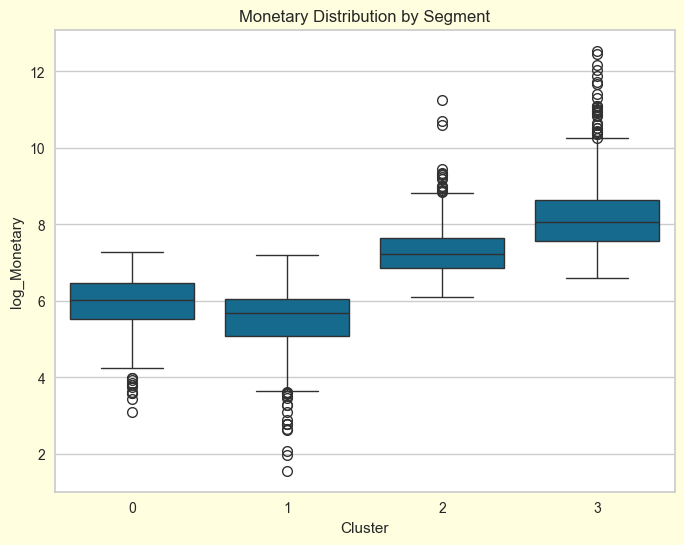

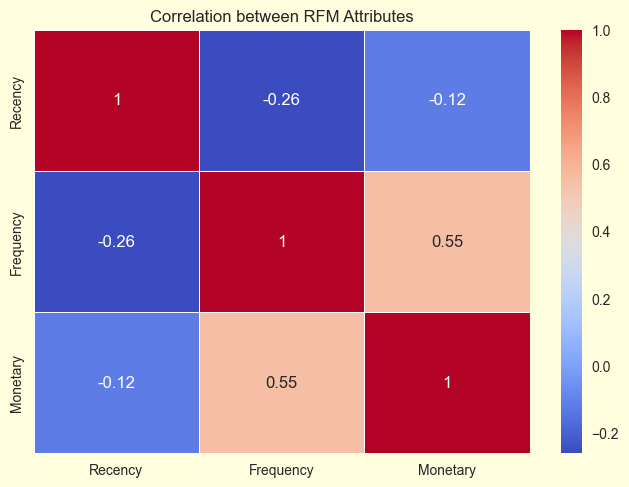

In [164]:
# Monetary value distribution across segments (boxplot)
plt.figure(figsize=(8, 6))
sns.boxplot(x='Cluster', y='log_Monetary', data=rfm)
plt.title('Monetary Distribution by Segment')
plt.xticks(rotation=0)
plt.show()

# RFM Heatmap
rfm_heatmap_data = rfm[['Recency', 'Frequency', 'Monetary']].corr()
sns.heatmap(rfm_heatmap_data, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation between RFM Attributes')
plt.show()

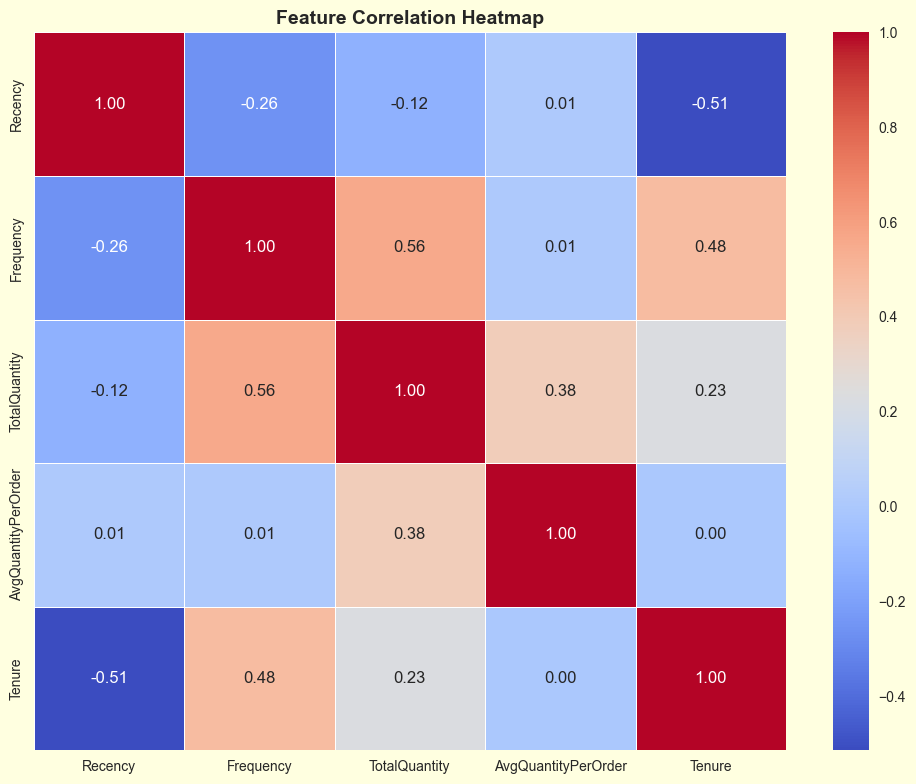

In [165]:
# Correlation analysis on Regression model features
plt.figure(figsize=(10, 8))
sns.heatmap(X.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

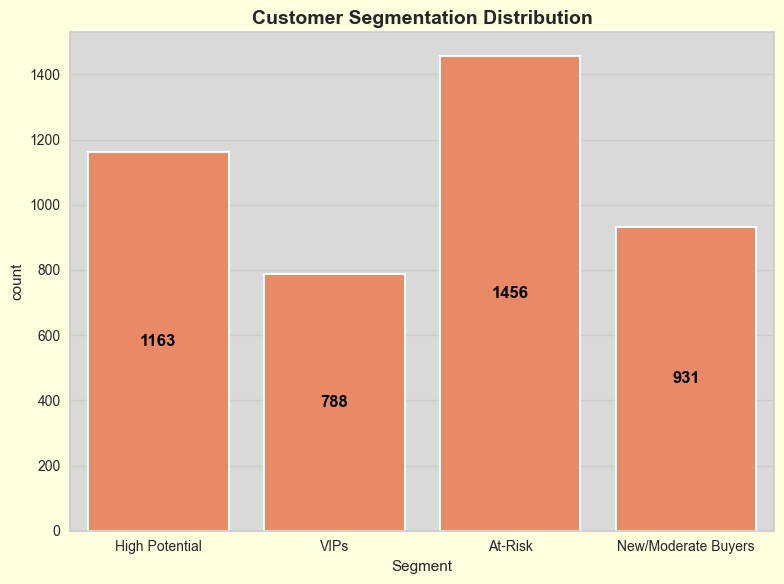

In [166]:
# ✅ Rename cluster labels
cluster_map = {
    3: "VIPs",
    2: "High Potential",
    0: "New/Moderate Buyers",
    1: "At-Risk"
}
rfm['Segment'] = rfm['Cluster'].map(cluster_map)

# ✅ Plot: Count of customers in each segment
plt.figure(figsize=(8, 6))
ax = sns.countplot(
    x='Segment',
    data=rfm,
    color='coral',       # Tableau orange
    edgecolor='white',
    linewidth=1.5
)

# Set background colors
ax.set_facecolor('#d9d9d9')            # Inner plot background (darker grey)
ax.figure.set_facecolor('lightyellow') # Outer background

# ✅ Annotate bars with count (centered, bold, larger font)
for p in ax.patches:
    count = int(p.get_height())
    ax.annotate(f'{count}',
                (p.get_x() + p.get_width() / 2, p.get_height() / 2),
                ha='center', va='center',
                fontsize=12, fontweight='bold', color='black')

# ✅ Title and formatting
plt.title('Customer Segmentation Distribution', fontsize=14, fontweight='bold')
plt.xticks(rotation=0)

# ✅ Save and show
plt.tight_layout()
plt.savefig('cluster_distribution_tab_orange.png', dpi=300, bbox_inches='tight')
plt.show()

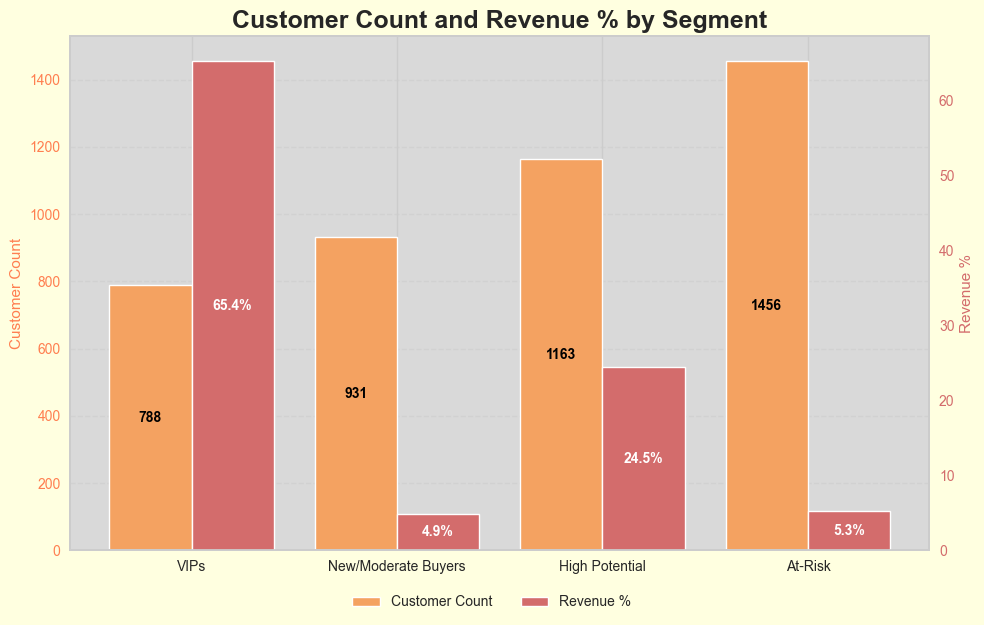

In [167]:
# Prepare data
segment_order = rfm['Segment'].value_counts().sort_values().index

# Count and revenue % per segment
count_series = rfm['Segment'].value_counts().loc[segment_order]
revenue_series = rfm.groupby('Segment')['Monetary'].sum().loc[segment_order]
revenue_percent = (revenue_series / revenue_series.sum()) * 100

# Set bar positions
x = range(len(segment_order))
bar_width = 0.4

# Create figure and axes
fig, ax1 = plt.subplots(figsize=(10, 6))
ax2 = ax1.twinx()

# Plot bars
bars1 = ax1.bar(
    [i - bar_width / 2 for i in x],
    count_series.values,
    width=bar_width,
    label='Customer Count',
    color='#f4a261',  # Lighter orange
    edgecolor='white',
    linewidth=1
)

bars2 = ax2.bar(
    [i + bar_width / 2 for i in x],
    revenue_percent.values,
    width=bar_width,
    label='Revenue %',
    color='#d36c6c',  # Darker pink
    edgecolor='white',
    linewidth=1
)

# Set x-axis
ax1.set_xticks(x)
ax1.set_xticklabels(segment_order)

# Axis labels and tick colors
ax1.set_ylabel('Customer Count', color='coral')     # Reverted to previous orange
ax2.set_ylabel('Revenue %', color='#d36c6c')         # Keep pink

ax1.tick_params(axis='y', colors='coral')            # Reverted y-axis ticks to coral
ax2.tick_params(axis='y', colors='#d36c6c')          # Keep pink

# Title
plt.title('Customer Count and Revenue % by Segment', fontsize=18, fontweight='bold')

# Add annotations inside the bars
for bar in bars1:
    height = int(bar.get_height())
    ax1.annotate(f'{height}',
                 (bar.get_x() + bar.get_width() / 2, height / 2),
                 ha='center', va='center', fontsize=10, fontweight='bold', color='black')

for bar in bars2:
    height = bar.get_height()
    ax2.annotate(f'{height:.1f}%',
                 (bar.get_x() + bar.get_width() / 2, height / 2),
                 ha='center', va='center', fontsize=10, fontweight='bold', color='white')

# Grid and background
ax1.set_axisbelow(True)
ax1.yaxis.grid(True, linestyle='--', alpha=0.6)
ax2.yaxis.grid(False)

ax1.set_facecolor('#d9d9d9')
fig.patch.set_facecolor('lightyellow')

# Legend below
fig.legend(
    [bars1[0], bars2[0]],
    ['Customer Count', 'Revenue %'],
    loc='lower center',
    bbox_to_anchor=(0.5, -0.05),
    ncol=2,
    frameon=False
)

# Save and show
plt.tight_layout()
plt.savefig('segment_count&revenue_bar.png', dpi=300, bbox_inches='tight')
plt.show()


## 7. Dashboard
- Build an interactive dashboard using Streamlit.

In [169]:
#import joblib

In [170]:
# Save the model
#joblib.dump(kmeans, 'kmeans_model.pkl')

In [171]:
# Save model to a JSON file (recommended)
#xgb.save_model('xgb_model.json')

In [172]:
# Save the model
#joblib.dump(rf, 'rf_model.joblib')

## 8. Conclusion and Business Recommendations

Summary:
- Segmentation Insights: Explain how each segment behaves differently (e.g., VIPs vs. At-Risk customers).
- Recommendations: Tailor marketing strategies for each segment. (e.g. loyalty programs for "VIPs", win-back campaigns for "At Risk").
- Deploy a predictive model to predict CLV supplementing the segmentation model to enhance marketing strategies.

Assumptions and Limitations:
- Assuming all transactions are accurately recorded in the dataset.
- While the model is performing well with good accuracy, future enhancement can be made to improve performance further by injecting more features if data such as customers' attributes are made available. 